# Lección 3.2 · Programación dinámica: Needleman-Wunsch y Smith-Waterman

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-03-alineamiento/3.2_programacion_dinamica.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 3 — Alineamiento de secuencias** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio | Lecciones 0.1–0.3, 1.1–1.2 y 3.1 |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** qué es un alineamiento y cómo se le asigna un **puntaje**.
2. **Demostrar** con números por qué es imposible probar todos los alineamientos posibles (explosión combinatoria).
3. **Enunciar** el principio de optimalidad y **escribir** la recurrencia de Needleman-Wunsch.
4. **Llenar a mano** una matriz de programación dinámica y **reconstruir** el alineamiento óptimo (*traceback*).
5. **Distinguir** alineamiento global (Needleman-Wunsch), local (Smith-Waterman) y semiglobal, y **elegir** el
   adecuado para cada problema biológico.
6. **Medir** el costo $O(nm)$ del algoritmo y **verificar** su implementación contra Biopython.
7. **Aplicar** todo a un caso real: el dominio de unión al receptor (RBD) de la proteína Spike de SARS-CoV-2 frente
   al de SARS-CoV-1.

## 🗺️ Mapa de la clase

1. ¿Qué significa alinear dos secuencias?
2. El puntaje de un alineamiento
3. Por qué no podemos probarlos todos: la explosión combinatoria
4. La idea genial: el principio de optimalidad
5. El alineamiento como un camino en una cuadrícula
6. La recurrencia de Needleman-Wunsch, paso a paso a mano
7. 🎬 La matriz se llena celda por celda
8. 🎬 El *traceback*: de la matriz al alineamiento
9. 🧪 Implementación y verificación contra Biopython
10. Alineamiento local: Smith-Waterman
11. ¿Cuánto cuesta un hueco? Penalizaciones lineales y afines
12. 🧪 El costo del algoritmo: tiempo y memoria
13. 🧪 Caso real: el RBD de SARS-CoV-2 frente al de SARS-CoV-1
14. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import time, math, itertools
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import FancyArrowPatch, Rectangle

try:
    import Bio
except ImportError:
    %pip install -q biopython
from Bio import SeqIO
from Bio.Align import PairwiseAligner
RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

# Colores con significado fijo durante toda la lección
C_DIAG, C_UP, C_LEFT = ec.BLUE, ec.ORANGE, ec.AQUA        # diagonal · hueco en B · hueco en A
C_MATCH, C_MISMATCH, C_GAP = ec.BLUE, ec.ORANGE, ec.BASELINE

Entorno listo ✔  |  Colab: False


## 1. ¿Qué significa alinear dos secuencias?

Imagine que dos personas copian a mano el mismo párrafo. Al comparar las dos copias encontrará tres tipos de
diferencias: una letra cambiada por otra, una letra que sobra en una copia y una letra que falta. Si quiere saber
**qué letra corresponde a qué letra**, pone las dos copias una encima de la otra y, donde una copia tiene una letra
de más, deja un **espacio en blanco** en la otra para que el resto del texto vuelva a coincidir.

Eso es exactamente un **alineamiento**: escribir dos secuencias una sobre otra, insertando **huecos** (`-`) donde
haga falta, de modo que las posiciones que vienen del mismo ancestro queden en la misma columna.

```
G A T T A C A -          ← secuencia A
| . | |   | |            ← | = igual (match), . = distinta (mismatch)
G C A T - G C U          ← secuencia B
```

Cada **columna** del alineamiento puede ser de tres tipos:

| Columna | Qué significa biológicamente | Ejemplo |
|---|---|---|
| **Coincidencia** (*match*) | la base se conservó desde el ancestro común | `A` sobre `A` |
| **Sustitución** (*mismatch*) | una mutación puntual cambió la base | `A` sobre `C` |
| **Hueco** (*gap*, *indel*) | una inserción en una secuencia o una deleción en la otra | `A` sobre `-` |

Nunca se alinea un hueco con otro hueco: esa columna no diría nada.

La pregunta de esta clase es: **de todos los alineamientos posibles, ¿cuál es el mejor, y cómo lo encontramos sin
morir en el intento?**

## 2. El puntaje de un alineamiento

Para decidir cuál alineamiento es "mejor" necesitamos un número. La idea es sencilla: sumamos **premios** por las
coincidencias y **castigos** por las sustituciones y los huecos, como en un examen donde cada respuesta correcta
suma y cada error resta.

$$
S(\text{alineamiento}) \;=\; \sum_{\text{columnas } c} \sigma(c),
\qquad
\sigma(c) =
\begin{cases}
\;\;\;s_{\text{match}} & \text{si las dos letras son iguales}\\
\;\;\;s_{\text{mismatch}} & \text{si las dos letras son distintas}\\
\;\;\;d & \text{si una de las dos es un hueco}
\end{cases}
$$

| Símbolo | Significado | Valor en esta clase |
|---|---|---|
| $S$ | puntaje total del alineamiento (más alto = mejor) | — |
| $c$ | una columna del alineamiento | — |
| $\sigma(c)$ | puntaje de esa columna | — |
| $s_{\text{match}}$ | premio por coincidencia | $+1$ |
| $s_{\text{mismatch}}$ | castigo por sustitución | $-1$ |
| $d$ | castigo por hueco (*gap penalty*) | $-1$ |

### Ejemplo a mano

Puntuemos tres alineamientos distintos de `GATTACA` y `GCATGCU`:

| | Alineamiento | Columnas | Cuenta | $S$ |
|---|---|---|---|---|
| (a) | `GATTACA` / `GCATGCU` | 3 match, 4 mismatch | $3(+1) + 4(-1)$ | $-1$ |
| (b) | `G-ATTACA` / `GCA-TGCU` | 4 match, 2 mismatch, 2 huecos | $4 - 2 - 2$ | $0$ |
| (c) | `GATTACA-` / `GCAT-GCU` | … ¡calcúlelo usted con el código! | | |

Escribamos una función que haga esta cuenta por nosotros:

In [2]:
MATCH, MISMATCH, GAP = 1, -1, -1

def score_alignment(top: str, bottom: str, match=MATCH, mismatch=MISMATCH, gap=GAP) -> int:
    """Puntaje de un alineamiento ya escrito (dos cadenas de igual longitud con '-')."""
    assert len(top) == len(bottom), "las dos filas deben tener la misma longitud"
    total = 0
    for x, y in zip(top, bottom):
        if x == "-" or y == "-":
            total += gap
        elif x == y:
            total += match
        else:
            total += mismatch
    return total

def show_alignment(top: str, bottom: str) -> None:
    """Imprime el alineamiento con una línea central: | igual, . distinta, espacio = hueco."""
    mid = "".join("|" if x == y else (" " if "-" in (x, y) else ".") for x, y in zip(top, bottom))
    print("   " + "  ".join(top)); print("   " + "  ".join(mid)); print("   " + "  ".join(bottom))

candidates = [("GATTACA", "GCATGCU"), ("G-ATTACA", "GCA-TGCU"), ("GATTACA-", "GCAT-GCU")]
for top, bottom in candidates:
    show_alignment(top, bottom)
    print(f"   puntaje S = {score_alignment(top, bottom)}\n")

   G  A  T  T  A  C  A
   |  .  .  |  .  |  .
   G  C  A  T  G  C  U
   puntaje S = -1

   G  -  A  T  T  A  C  A
   |     |     |  .  |  .
   G  C  A  -  T  G  C  U
   puntaje S = 0

   G  A  T  T  A  C  A  -
   |  .  .  |     .  .   
   G  C  A  T  -  G  C  U
   puntaje S = -4



> 🔎 **Qué observamos.** Alineamientos distintos de las **mismas** secuencias dan puntajes distintos. Mover un
> hueco de lugar cambia qué letras quedan enfrentadas. El "mejor" alineamiento es el de **puntaje máximo**…
> pero ¿cómo sabemos que no hay otro, todavía mejor, que no se nos ocurrió?

## 3. Por qué no podemos probarlos todos

La primera idea es la de "fuerza bruta": escribir **todos** los alineamientos posibles, puntuar cada uno y quedarnos
con el mejor. Veamos cuántos hay.

Cada alineamiento se puede describir como una sucesión de tres movimientos: **avanzar en las dos secuencias**
(columna letra-letra), **avanzar sólo en A** (hueco en B) o **avanzar sólo en B** (hueco en A). El número de maneras
distintas de combinar esos pasos para recorrer dos secuencias de longitud $n$ y $m$ es el **número de Delannoy**
$D(n, m)$, que cumple una regla muy simple:

$$
D(n, m) \;=\; D(n-1,\, m-1) \;+\; D(n-1,\, m) \;+\; D(n,\, m-1),
\qquad D(n, 0) = D(0, m) = 1
$$

| Símbolo | Significado |
|---|---|
| $D(n,m)$ | número de alineamientos distintos entre una secuencia de $n$ letras y otra de $m$ |
| $D(n-1,m-1)$ | los que terminan con una columna letra-letra |
| $D(n-1,m)$, $D(n,m-1)$ | los que terminan con un hueco en B o en A |

Para dos secuencias de igual longitud $n$, el libro clásico de Durbin *et al.* usa la aproximación (que cuenta como
iguales ciertos alineamientos equivalentes y por eso es una **cota inferior**):

$$
\binom{2n}{n} \;\approx\; \frac{2^{2n}}{\sqrt{\pi n}}
$$

Con $n = 7$ (¡nuestro ejemplo de juguete!) ya hay $D(7,7) = 48\,639$ alineamientos. Con $n = 300$, una proteína
pequeña…

🤔 **Antes de ejecutar, prediga:** ¿cuántos alineamientos cree que hay entre dos proteínas de 300 aminoácidos?
¿Más o menos que los átomos del universo observable ($\approx 10^{80}$)?

In [3]:
def delannoy(n: int, m: int) -> int:
    """Número de alineamientos globales distintos (enteros exactos de Python, sin desbordamiento)."""
    D = [[1] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            D[i][j] = D[i - 1][j - 1] + D[i - 1][j] + D[i][j - 1]
    return D[n][m]

for n in [3, 7, 20, 100, 300]:
    d = delannoy(n, n)
    print(f"n = {n:>3}:  D(n,n) ≈ 10^{math.log10(d):6.1f}   ·  C(2n,n) ≈ 10^{math.log10(math.comb(2*n, n)):6.1f}"
          f"   ·  celdas de la matriz DP = {n*n:,}")

n =   3:  D(n,n) ≈ 10^   1.8   ·  C(2n,n) ≈ 10^   1.3   ·  celdas de la matriz DP = 9
n =   7:  D(n,n) ≈ 10^   4.7   ·  C(2n,n) ≈ 10^   3.5   ·  celdas de la matriz DP = 49
n =  20:  D(n,n) ≈ 10^  14.4   ·  C(2n,n) ≈ 10^  11.1   ·  celdas de la matriz DP = 400
n = 100:  D(n,n) ≈ 10^  75.3   ·  C(2n,n) ≈ 10^  59.0   ·  celdas de la matriz DP = 10,000
n = 300:  D(n,n) ≈ 10^ 228.2   ·  C(2n,n) ≈ 10^ 179.1   ·  celdas de la matriz DP = 90,000


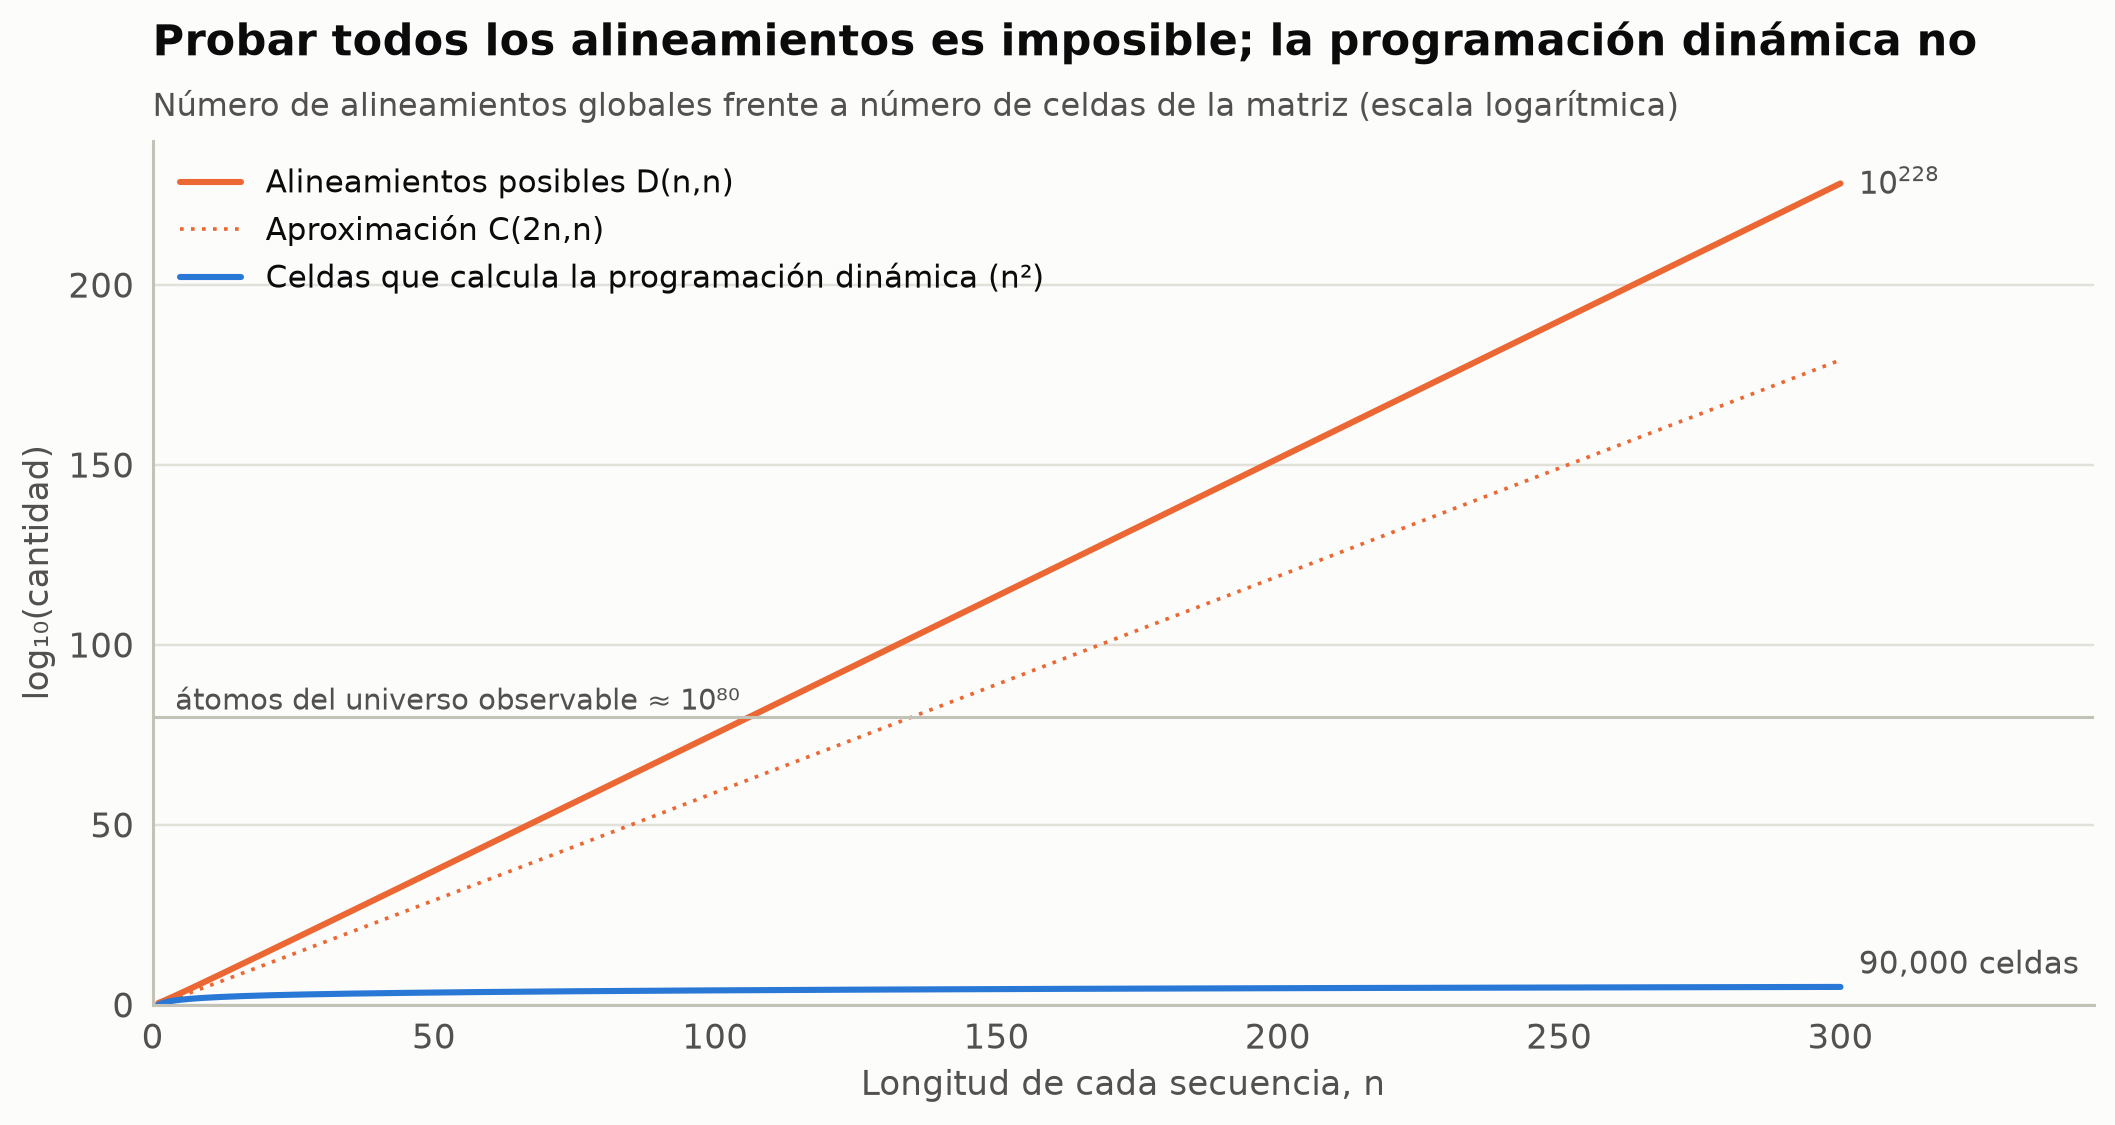

In [4]:
ns = np.arange(1, 301)
log_del = np.array([math.log10(delannoy(n, n)) for n in ns])
log_comb = np.array([math.log10(math.comb(2 * n, n)) for n in ns])
log_cells = np.log10(ns.astype(float) ** 2)

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(ns, log_del, color=ec.ORANGE, label="Alineamientos posibles D(n,n)")
ax.plot(ns, log_comb, color=ec.ORANGE, lw=1.2, ls=(0, (1, 2)), label="Aproximación C(2n,n)")
ax.plot(ns, log_cells, color=ec.BLUE, label="Celdas que calcula la programación dinámica (n²)")
ax.axhline(80, color=ec.BASELINE, lw=1)
ax.text(4, 82, "átomos del universo observable ≈ 10⁸⁰", color=ec.INK_2, fontsize=9.5)
ec.label_end(ax, ns[-1], log_del[-1], f"$10^{{{log_del[-1]:.0f}}}$")
ec.label_end(ax, ns[-1], log_cells[-1] + 6, f"{ns[-1]**2:,} celdas")
ax.set_xlim(0, 345); ax.set_ylim(0, 240)
ax.set_xlabel("Longitud de cada secuencia, n")
ax.set_ylabel("log₁₀(cantidad)")
ax.legend(loc="upper left")
ec.title(ax, "Probar todos los alineamientos es imposible; la programación dinámica no",
         "Número de alineamientos globales frente a número de celdas de la matriz (escala logarítmica)")
plt.show()

> 🔎 **Qué observamos.** La curva naranja crece **exponencialmente**: para dos proteínas de 300 aminoácidos hay
> del orden de $10^{230}$ alineamientos. Aunque una computadora evaluara mil millones por segundo desde el Big Bang,
> no habría revisado ni una fracción despreciable. La curva azul, en cambio, crece como $n^2$: **90 000 celdas**.
> Toda la magia de esta clase está en pasar de la curva naranja a la azul.

## 4. La idea genial: el principio de optimalidad

Suponga que la ruta más rápida para ir de su casa a la universidad pasa por la plaza central. Entonces el tramo
**casa → plaza** de esa ruta tiene que ser también la ruta más rápida de su casa a la plaza. ¿Por qué? Porque si
existiera un camino más rápido hasta la plaza, lo usaría y llegaría antes a la universidad, lo cual contradice que
la ruta original era la más rápida.

Esa observación se llama **principio de optimalidad** (Richard Bellman, años 50) y es la base de la
**programación dinámica**:

> Una solución óptima está hecha de soluciones óptimas de subproblemas más pequeños.

Aplicado a alineamientos: el mejor alineamiento de `GATTACA` con `GCATGCU` **termina** de una de tres maneras
(con `A/U`, con `A/-` o con `-/U`). Lo que va antes de esa última columna tiene que ser, a su vez, el **mejor
alineamiento de los prefijos** que quedan. Así, en lugar de mirar $10^{230}$ alineamientos completos, resolvemos
problemas pequeños (prefijos cortos), **guardamos** sus respuestas en una tabla y las reutilizamos. Guardar
resultados parciales para no recalcularlos es la esencia de la programación dinámica: es como anotar en un cuaderno
el resultado de cada suma parcial en lugar de volver a sumar desde el principio cada vez.

## 5. El alineamiento como un camino en una cuadrícula

Pongamos la secuencia **A** a lo largo de las **filas** y la secuencia **B** a lo largo de las **columnas** de una
cuadrícula. Cada alineamiento es un **camino** desde la esquina superior izquierda hasta la inferior derecha usando
sólo tres pasos:

| Paso en la cuadrícula | Columna del alineamiento | Color en esta clase |
|---|---|---|
| ↘ diagonal | letra de A sobre letra de B (match o mismatch) | azul |
| ↓ hacia abajo | letra de A sobre hueco (`A/-`) | naranja |
| → hacia la derecha | hueco sobre letra de B (`-/B`) | aqua |

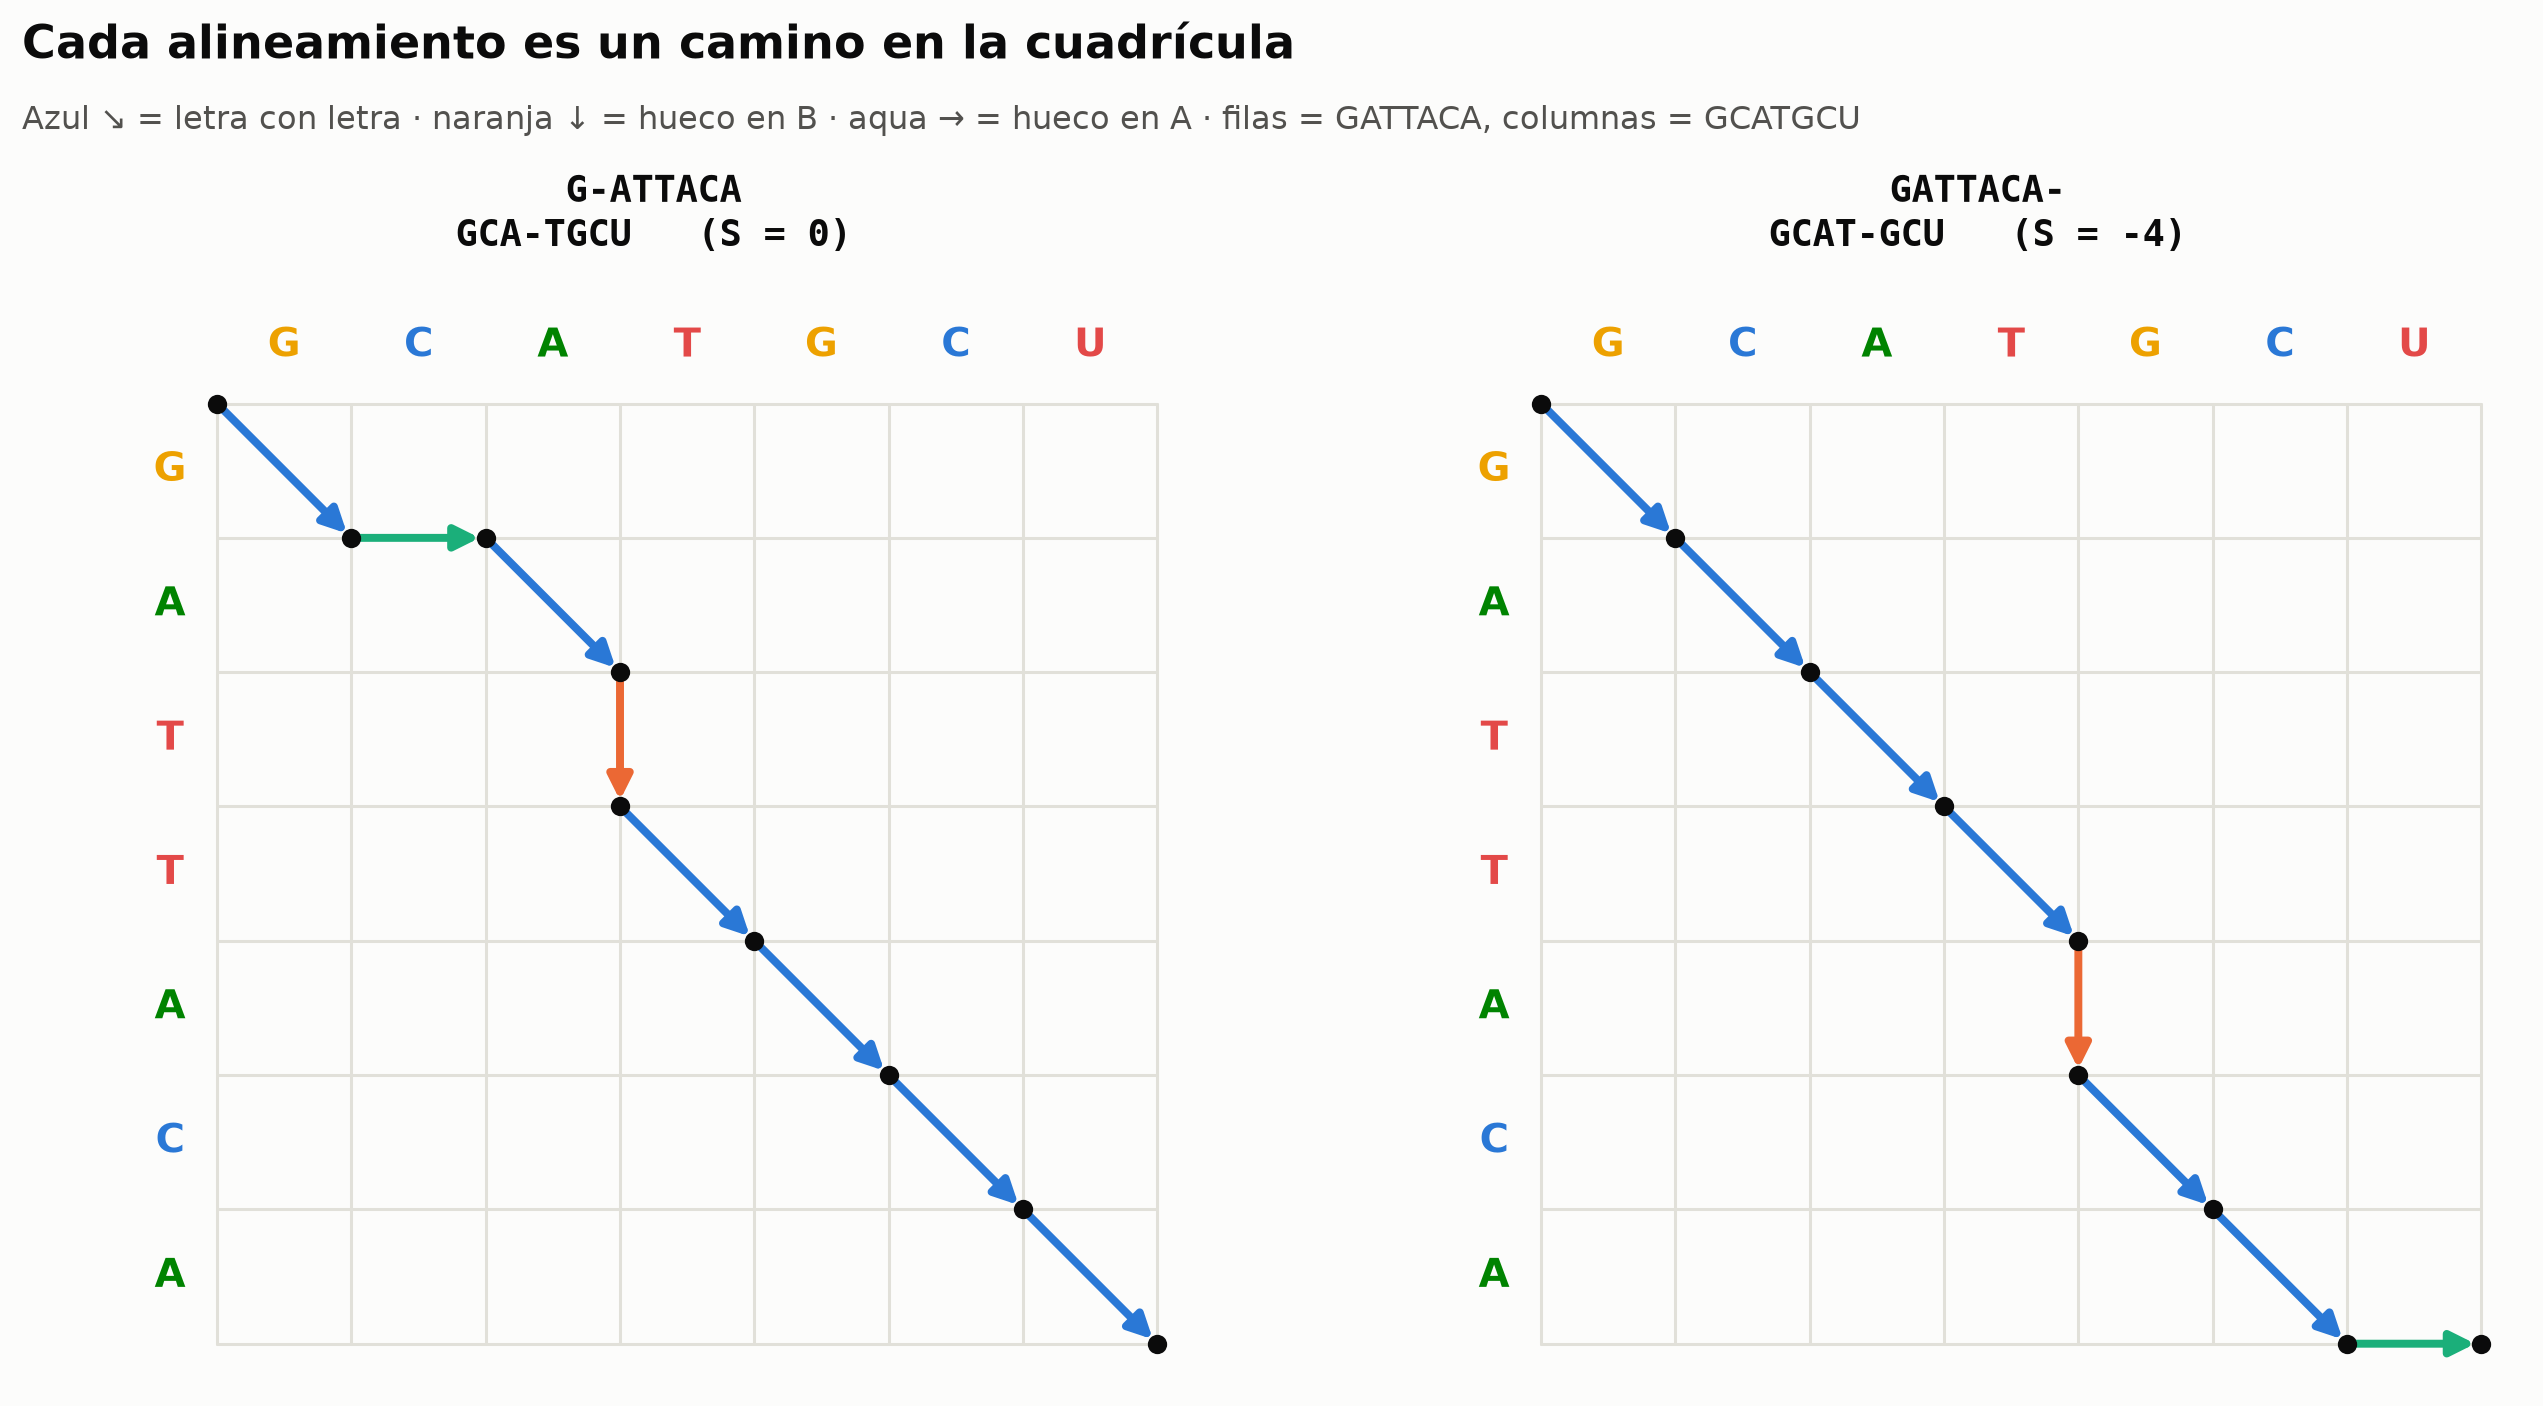

In [5]:
A, B = "GATTACA", "GCATGCU"

def path_from_alignment(top, bottom):
    """Convierte un alineamiento escrito en la lista de celdas (i, j) que recorre."""
    i = j = 0; path = [(0, 0)]
    for x, y in zip(top, bottom):
        if x != "-": i += 1
        if y != "-": j += 1
        path.append((i, j))
    return path

fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
examples = [("G-ATTACA", "GCA-TGCU"), ("GATTACA-", "GCAT-GCU")]
for ax, (top, bottom) in zip(axes, examples):
    for k in range(len(A) + 1):
        ax.plot([0, len(B)], [k, k], color=ec.GRID, lw=1, zorder=0)
    for k in range(len(B) + 1):
        ax.plot([k, k], [0, len(A)], color=ec.GRID, lw=1, zorder=0)
    path = path_from_alignment(top, bottom)
    for (i0, j0), (i1, j1) in zip(path[:-1], path[1:]):
        color = C_DIAG if (i1 > i0 and j1 > j0) else (C_UP if i1 > i0 else C_LEFT)
        ax.annotate("", xy=(j1, i1), xytext=(j0, i0),
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=2.6, mutation_scale=16))
    ax.scatter(*zip(*[(j, i) for i, j in path]), s=40, color=ec.INK, zorder=3)
    for k, b in enumerate(B):
        ax.text(k + 0.5, -0.35, b, ha="center", fontsize=13, fontweight="bold", color=ec.NUC_COLORS.get(b, ec.INK_2))
    for k, a in enumerate(A):
        ax.text(-0.35, k + 0.5, a, va="center", ha="center", fontsize=13, fontweight="bold", color=ec.NUC_COLORS.get(a, ec.INK_2))
    ax.set_xlim(-0.8, len(B) + 0.3); ax.set_ylim(len(A) + 0.3, -0.9)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{top}\n{bottom}   (S = {score_alignment(top, bottom)})", fontsize=12,
                 family="DejaVu Sans Mono", loc="center")
ec.fig_title(fig, "Cada alineamiento es un camino en la cuadrícula",
             "Azul ↘ = letra con letra · naranja ↓ = hueco en B · aqua → = hueco en A · filas = GATTACA, columnas = GCATGCU")
plt.show()

> 🔎 **Qué observamos.** Dos alineamientos distintos son dos caminos distintos en la **misma** cuadrícula. Buscar el
> mejor alineamiento es buscar el **camino de mayor puntaje**, como buscar la ruta más rentable en un mapa de
> calles donde cada cuadra tiene un premio o un peaje.

✅ **Compruebe su comprensión.** ¿Cuántos pasos diagonales, hacia abajo y hacia la derecha tiene el alineamiento
`GATTACA-` / `GCAT-GCU`? ¿Por qué el número de pasos hacia abajo más el de diagonales siempre suma 7?

## 6. La recurrencia de Needleman-Wunsch

Definimos $F(i, j)$ como **el mejor puntaje posible** al alinear las primeras $i$ letras de A con las primeras $j$
letras de B. Por el principio de optimalidad, a la celda $(i, j)$ sólo se puede llegar desde tres vecinas, así que:

$$
F(i, j) \;=\; \max
\begin{cases}
F(i-1,\, j-1) \;+\; s(a_i, b_j) & \color{#2a78d6}{\searrow \;\text{ alinear } a_i \text{ con } b_j}\\[4pt]
F(i-1,\, j) \;+\; d & \color{#eb6834}{\downarrow \;\text{ } a_i \text{ con un hueco}}\\[4pt]
F(i,\, j-1) \;+\; d & \color{#1baf7a}{\rightarrow \;\text{ } b_j \text{ con un hueco}}
\end{cases}
$$

con la **inicialización** de la primera fila y columna (alinear un prefijo contra nada sólo puede hacerse con huecos):

$$
F(0,0)=0, \qquad F(i,0) = i\cdot d, \qquad F(0,j) = j\cdot d
$$

| Símbolo | Significado |
|---|---|
| $F(i,j)$ | mejor puntaje para los prefijos $a_1 \dots a_i$ y $b_1 \dots b_j$ |
| $a_i$, $b_j$ | la $i$-ésima letra de A y la $j$-ésima letra de B |
| $s(a_i, b_j)$ | $+1$ si son iguales, $-1$ si son distintas (en la Lección 3.3 lo reemplazaremos por BLOSUM) |
| $d$ | castigo por hueco ($-1$) |
| $F(n, m)$ | **la respuesta**: el puntaje del mejor alineamiento global |

Además de guardar el valor, anotamos **de dónde vino** (qué opción ganó): esas flechas de regreso nos permitirán
reconstruir el alineamiento al final.

### Tres celdas calculadas a mano

Con A = `GATTACA` (filas) y B = `GCATGCU` (columnas), la primera fila vale $0, -1, -2, \dots, -7$ y la primera
columna también.

* **Celda $(1,1)$**: $a_1 = $ `G`, $b_1 = $ `G` → coinciden.
  $\max\{F(0,0)+1,\; F(0,1)-1,\; F(1,0)-1\} = \max\{0+1,\;-1-1,\;-1-1\} = \max\{1, -2, -2\} = \mathbf{1}$ ↘
* **Celda $(1,2)$**: `G` frente a `C` → distintas.
  $\max\{F(0,1)-1,\; F(0,2)-1,\; F(1,1)-1\} = \max\{-2,\;-3,\;0\} = \mathbf{0}$ →
* **Celda $(2,3)$**: `A` frente a `A` → coinciden.
  $\max\{F(1,2)+1,\; F(1,3)-1,\; F(2,2)-1\} = \max\{0+1,\; -1-1,\; 0-1\} = \mathbf{1}$ ↘

Siga este ritmo fila por fila y habrá llenado toda la tabla. Hagámoslo en código y dibujemos el resultado.

In [6]:
DIAG, UP, LEFT = 0, 1, 2          # códigos de la flecha ganadora (orden de preferencia en empates)

def needleman_wunsch(a: str, b: str, match=MATCH, mismatch=MISMATCH, gap=GAP):
    """Devuelve la matriz de puntajes F, la matriz de flechas T y los candidatos de cada celda."""
    n, m = len(a), len(b)
    F = np.zeros((n + 1, m + 1))
    T = np.full((n + 1, m + 1), -1)
    cand = np.full((n + 1, m + 1, 3), np.nan)          # (diag, up, left) para enseñar
    F[:, 0] = np.arange(n + 1) * gap; T[1:, 0] = UP
    F[0, :] = np.arange(m + 1) * gap; T[0, 1:] = LEFT
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            s = match if a[i - 1] == b[j - 1] else mismatch
            options = (F[i - 1, j - 1] + s, F[i - 1, j] + gap, F[i, j - 1] + gap)
            k = int(np.argmax(options))                # en empate gana diag > up > left
            F[i, j], T[i, j] = options[k], k
            cand[i, j] = options
    return F, T, cand

def traceback(a: str, b: str, T: np.ndarray, i=None, j=None, stop_at_zero=None):
    """Sigue las flechas desde (i, j) hasta el origen y reconstruye el alineamiento."""
    i = len(a) if i is None else i; j = len(b) if j is None else j
    top, bottom, path = [], [], [(i, j)]
    while (i > 0 or j > 0) and not (stop_at_zero is not None and stop_at_zero[i, j] == 0):
        move = T[i, j]
        if move == DIAG:
            top.append(a[i - 1]); bottom.append(b[j - 1]); i, j = i - 1, j - 1
        elif move == UP:
            top.append(a[i - 1]); bottom.append("-"); i -= 1
        else:
            top.append("-"); bottom.append(b[j - 1]); j -= 1
        path.append((i, j))
    return "".join(reversed(top)), "".join(reversed(bottom)), path[::-1]

F, T, cand = needleman_wunsch(A, B)
top, bottom, path = traceback(A, B, T)
print("Matriz F:\n", F.astype(int))
print(f"\nPuntaje óptimo F(n, m) = {F[-1, -1]:.0f}\n")
show_alignment(top, bottom)

Matriz F:
 [[ 0 -1 -2 -3 -4 -5 -6 -7]
 [-1  1  0 -1 -2 -3 -4 -5]
 [-2  0  0  1  0 -1 -2 -3]
 [-3 -1 -1  0  2  1  0 -1]
 [-4 -2 -2 -1  1  1  0 -1]
 [-5 -3 -3 -1  0  0  0 -1]
 [-6 -4 -2 -2 -1 -1  1  0]
 [-7 -5 -3 -1 -2 -2  0  0]]

Puntaje óptimo F(n, m) = 0

   G  -  A  T  T  A  C  A
   |     |     |  .  |  .
   G  C  A  -  T  G  C  U


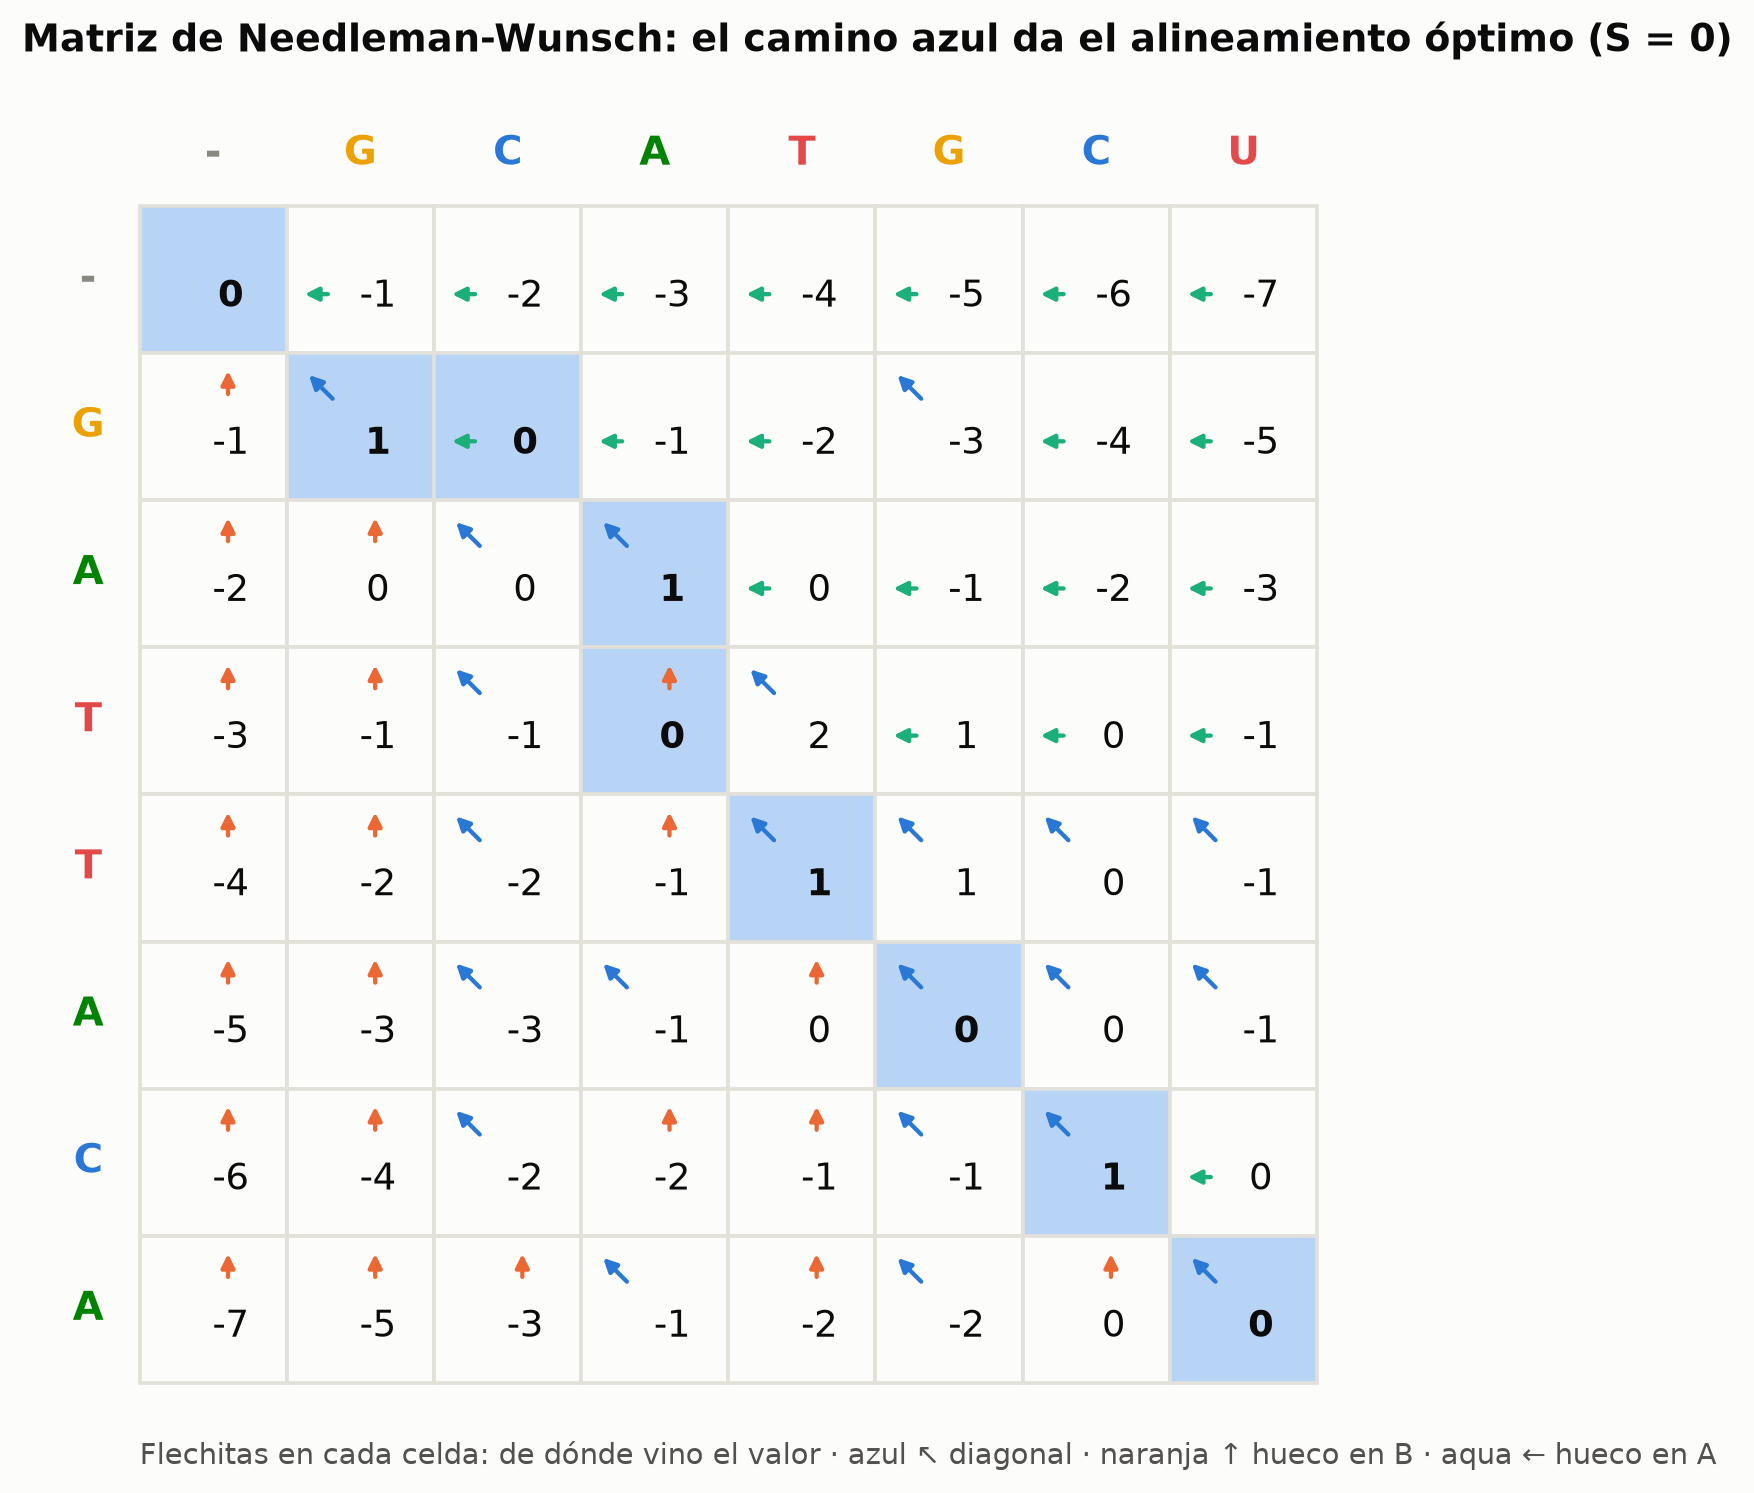

In [7]:
def draw_dp_matrix(ax, a, b, F, T, path=None, highlight=None, show_values=None, fs=12):
    """Dibuja la matriz DP con valores, flechas ganadoras y (opcional) el camino óptimo."""
    n, m = len(a), len(b)
    on_path = set(path or [])
    for i in range(n + 1):
        for j in range(m + 1):
            visible = show_values is None or show_values[i, j]
            face = ec.SEQ_BLUE[1] if (i, j) in on_path else ec.SURFACE
            ax.add_patch(Rectangle((j, i), 1, 1, facecolor=face, edgecolor=ec.GRID, lw=1.2))
            if visible:
                bold = (i, j) in on_path
                ax.text(j + 0.62, i + 0.62, f"{F[i, j]:.0f}", ha="center", va="center", fontsize=fs,
                        color=ec.INK, fontweight="bold" if bold else "normal")
                if T[i, j] >= 0:        # flechita en la esquina: de dónde vino el valor
                    color = [C_DIAG, C_UP, C_LEFT][T[i, j]]
                    x0, y0 = {DIAG: (j + 0.12, i + 0.12), UP: (j + 0.6, i + 0.08), LEFT: (j + 0.08, i + 0.6)}[T[i, j]]
                    dx, dy = {DIAG: (0.22, 0.22), UP: (0, 0.24), LEFT: (0.24, 0)}[T[i, j]]
                    ax.annotate("", xy=(x0, y0), xytext=(x0 + dx, y0 + dy),
                                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.4, mutation_scale=9))
    if highlight is not None:
        ax.add_patch(Rectangle((highlight[1], highlight[0]), 1, 1, fill=False, edgecolor=ec.INK, lw=3))
    for j, ch in enumerate("-" + b):
        ax.text(j + 0.5, -0.35, ch, ha="center", va="center", fontsize=fs + 1, fontweight="bold",
                color=ec.NUC_COLORS.get(ch, ec.MUTED))
    for i, ch in enumerate("-" + a):
        ax.text(-0.35, i + 0.5, ch, ha="center", va="center", fontsize=fs + 1, fontweight="bold",
                color=ec.NUC_COLORS.get(ch, ec.MUTED))
    ax.set_xlim(-0.8, m + 1.05); ax.set_ylim(n + 1.05, -0.8)
    ax.set_aspect("equal"); ax.axis("off")

fig, ax = plt.subplots(figsize=(7.8, 7.4))
draw_dp_matrix(ax, A, B, F, T, path=path)
ax.set_title(f"Matriz de Needleman-Wunsch: el camino azul da el alineamiento óptimo (S = {F[-1,-1]:.0f})",
             loc="left", fontsize=12.5)
ax.text(0, len(A) + 1.55, "Flechitas en cada celda: de dónde vino el valor · azul ↖ diagonal · naranja ↑ hueco en B"
        " · aqua ← hueco en A", fontsize=9.5, color=ec.INK_2)
plt.show()

> 🔎 **Qué observamos.** Cada celda guarda dos cosas: un **número** (el mejor puntaje hasta ahí) y una **flechita**
> (qué vecina lo produjo). El puntaje óptimo está en la esquina inferior derecha. Las celdas sombreadas son el camino
> que se obtiene siguiendo las flechitas **hacia atrás** desde esa esquina: ese camino **es** el alineamiento.

## 7. 🎬 La matriz se llena celda por celda

La animación muestra cómo el algoritmo recorre la tabla fila por fila. En cada celda aparecen las **tres flechas
candidatas** con el valor que propondría cada una; la ganadora se dibuja gruesa. A la derecha se escribe la cuenta
completa, igual que la hicimos a mano.

🤔 **Antes de ver la animación, prediga:** ¿en qué celdas cree que ganará la flecha diagonal? (Pista: mire dónde la
letra de la fila coincide con la de la columna.)

![Vista previa: la matriz de Needleman-Wunsch se llena celda por celda (GATTACA frente a GCATGCU)](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-03-alineamiento/3.2_llenado_matriz.gif)

*Vista previa: la matriz de Needleman-Wunsch se llena celda por celda (GATTACA frente a GCATGCU)*

In [8]:
cells = [(i, j) for i in range(1, len(A) + 1) for j in range(1, len(B) + 1)]
frames = cells + [cells[-1]] * 4                           # unas pausas al final

fig, (ax, ax_txt) = plt.subplots(1, 2, figsize=(11, 6.2), width_ratios=[1.35, 1])

def update(f):
    ax.clear(); ax_txt.clear(); ax_txt.axis("off")
    i, j = frames[f]
    shown = np.zeros_like(F, dtype=bool); shown[0, :] = True; shown[:, 0] = True
    for (ii, jj) in cells[: cells.index((i, j)) + 1]:
        shown[ii, jj] = True
    draw_dp_matrix(ax, A, B, F, T, highlight=(i, j), show_values=shown, fs=11)
    options = cand[i, j]
    sources = [(i - 1, j - 1), (i - 1, j), (i, j - 1)]
    for k, (si, sj) in enumerate(sources):
        win = k == T[i, j]
        ax.add_patch(FancyArrowPatch((sj + 0.5, si + 0.5), (j + 0.5, i + 0.5),
                                     arrowstyle="-|>", mutation_scale=18, lw=3.2 if win else 1.3,
                                     color=[C_DIAG, C_UP, C_LEFT][k], alpha=1 if win else 0.55, zorder=5))
    s = MATCH if A[i - 1] == B[j - 1] else MISMATCH
    rel = "coinciden → +1" if s > 0 else "distintas → −1"
    lines = [
        (f"Celda F({i},{j})", 16, "bold", ec.INK),
        (f"{A[i-1]} (fila)  vs  {B[j-1]} (columna):  {rel}", 11.5, "normal", ec.INK_2),
        ("", 6, "normal", ec.INK),
        (f"↘ diagonal:  {F[i-1,j-1]:.0f} {s:+d}  = {options[0]:.0f}", 13, "bold" if T[i, j] == DIAG else "normal", C_DIAG),
        (f"↓ hueco en B: {F[i-1,j]:.0f} {GAP:+d}  = {options[1]:.0f}", 13, "bold" if T[i, j] == UP else "normal", C_UP),
        (f"→ hueco en A: {F[i,j-1]:.0f} {GAP:+d}  = {options[2]:.0f}", 13, "bold" if T[i, j] == LEFT else "normal", C_LEFT),
        ("", 6, "normal", ec.INK),
        (f"F({i},{j}) = máx = {F[i,j]:.0f}", 15, "bold", ec.INK),
    ]
    y = 0.9
    for text, size, weight, color in lines:
        ax_txt.text(0.02, y, text, fontsize=size, fontweight=weight, color=ec.INK,
                    transform=ax_txt.transAxes, family="DejaVu Sans Mono" if "=" in text and "máx" not in text else "DejaVu Sans")
        if color in (C_DIAG, C_UP, C_LEFT):
            ax_txt.add_patch(Rectangle((-0.04, y - 0.01), 0.03, 0.045, color=color, transform=ax_txt.transAxes,
                                       clip_on=False))
        y -= 0.085 if size > 7 else 0.04
    ax_txt.text(0.02, 0.1, f"celda {cells.index((i, j)) + 1} de {len(cells)}", fontsize=10, color=ec.MUTED,
                transform=ax_txt.transAxes)
    ax.set_title("Needleman-Wunsch: llenado de la matriz", loc="left", fontsize=13)
    return ()

ec.animate(fig, update, frames=len(frames), interval=450, name="3.2_llenado_matriz")

> 🔎 **Qué observamos.** Cada celda depende **sólo** de tres vecinas ya calculadas (arriba, izquierda y
> arriba-izquierda). Por eso el orden fila por fila funciona: cuando llegamos a una celda, sus tres vecinas ya
> tienen su mejor valor. Ninguna celda se calcula dos veces.

## 8. 🎬 El *traceback*: de la matriz al alineamiento

Llenar la matriz nos da el **puntaje** óptimo, pero no el alineamiento. Para obtenerlo partimos de la esquina
$(n, m)$ y seguimos las flechitas hacia atrás, como quien regresa a casa siguiendo las migas de pan que fue dejando.
Cada paso añade **una columna** al alineamiento, escrito de derecha a izquierda:

| Flecha | Columna que se agrega |
|---|---|
| ↖ diagonal | $a_i$ sobre $b_j$ |
| ↑ arriba | $a_i$ sobre `-` |
| ← izquierda | `-` sobre $b_j$ |

![Vista previa: el traceback sigue las flechas desde la esquina y construye el alineamiento columna por columna](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-03-alineamiento/3.2_traceback.gif)

*Vista previa: el traceback sigue las flechas desde la esquina y construye el alineamiento columna por columna*

In [9]:
steps = list(reversed(path))                               # de (n, m) hacia (0, 0)
frames_tb = list(range(1, len(steps) + 1)) + [len(steps)] * 4

fig, (ax, ax_al) = plt.subplots(2, 1, figsize=(7.8, 9.2), height_ratios=[4.2, 1])

def update(f):
    ax.clear(); ax_al.clear(); ax_al.axis("off")
    k = frames_tb[f]
    current = steps[:k]
    draw_dp_matrix(ax, A, B, F, T, path=current, highlight=current[-1], fs=11)
    for (i1, j1), (i0, j0) in zip(current[:-1], current[1:]):
        move = T[i1, j1]
        ax.add_patch(FancyArrowPatch((j1 + 0.5, i1 + 0.5), (j0 + 0.5, i0 + 0.5), arrowstyle="-|>",
                                     mutation_scale=18, lw=3, color=[C_DIAG, C_UP, C_LEFT][move], zorder=6))
    n_cols = k - 1
    tops, bots = top[len(top) - n_cols:] if n_cols else "", bottom[len(bottom) - n_cols:] if n_cols else ""
    total = len(top)
    for c in range(total):
        x = 0.08 + c * 0.1
        if c >= total - n_cols:
            idx = c
            t, b_ = top[idx], bottom[idx]
            kind = C_GAP if "-" in (t, b_) else (C_MATCH if t == b_ else C_MISMATCH)
            ax_al.add_patch(Rectangle((x - 0.04, 0.12), 0.08, 0.76, color=kind, alpha=0.25,
                                      transform=ax_al.transAxes))
            ax_al.text(x, 0.68, t, ha="center", va="center", fontsize=15, fontweight="bold",
                       transform=ax_al.transAxes, family="DejaVu Sans Mono")
            ax_al.text(x, 0.32, b_, ha="center", va="center", fontsize=15, fontweight="bold",
                       transform=ax_al.transAxes, family="DejaVu Sans Mono")
    ax_al.text(0.0, 0.98, "Alineamiento (se escribe de derecha a izquierda):", fontsize=10.5, color=ec.INK_2,
               transform=ax_al.transAxes, va="bottom")
    ax.set_title(f"Traceback: paso {k - 1} de {len(steps) - 1}", loc="left", fontsize=13)
    return ()

ec.animate(fig, update, frames=len(frames_tb), interval=650, name="3.2_traceback")

> 🔎 **Qué observamos.** El camino va desde la esquina inferior derecha hasta el origen. Las columnas azules son
> coincidencias, las naranjas sustituciones y las grises huecos. Si en alguna celda **dos flechas empataban**,
> existían **varios alineamientos igual de buenos**: el algoritmo elige uno según su regla de desempate (aquí,
> diagonal > arriba > izquierda). Por eso dos programas distintos pueden devolver alineamientos distintos con el
> mismo puntaje, y ambos son correctos.

### La matriz, explorable

Pase el cursor por cada celda: verá el valor $F(i,j)$, los **tres candidatos** y el movimiento elegido. Las
celdas marcadas forman el camino óptimo.

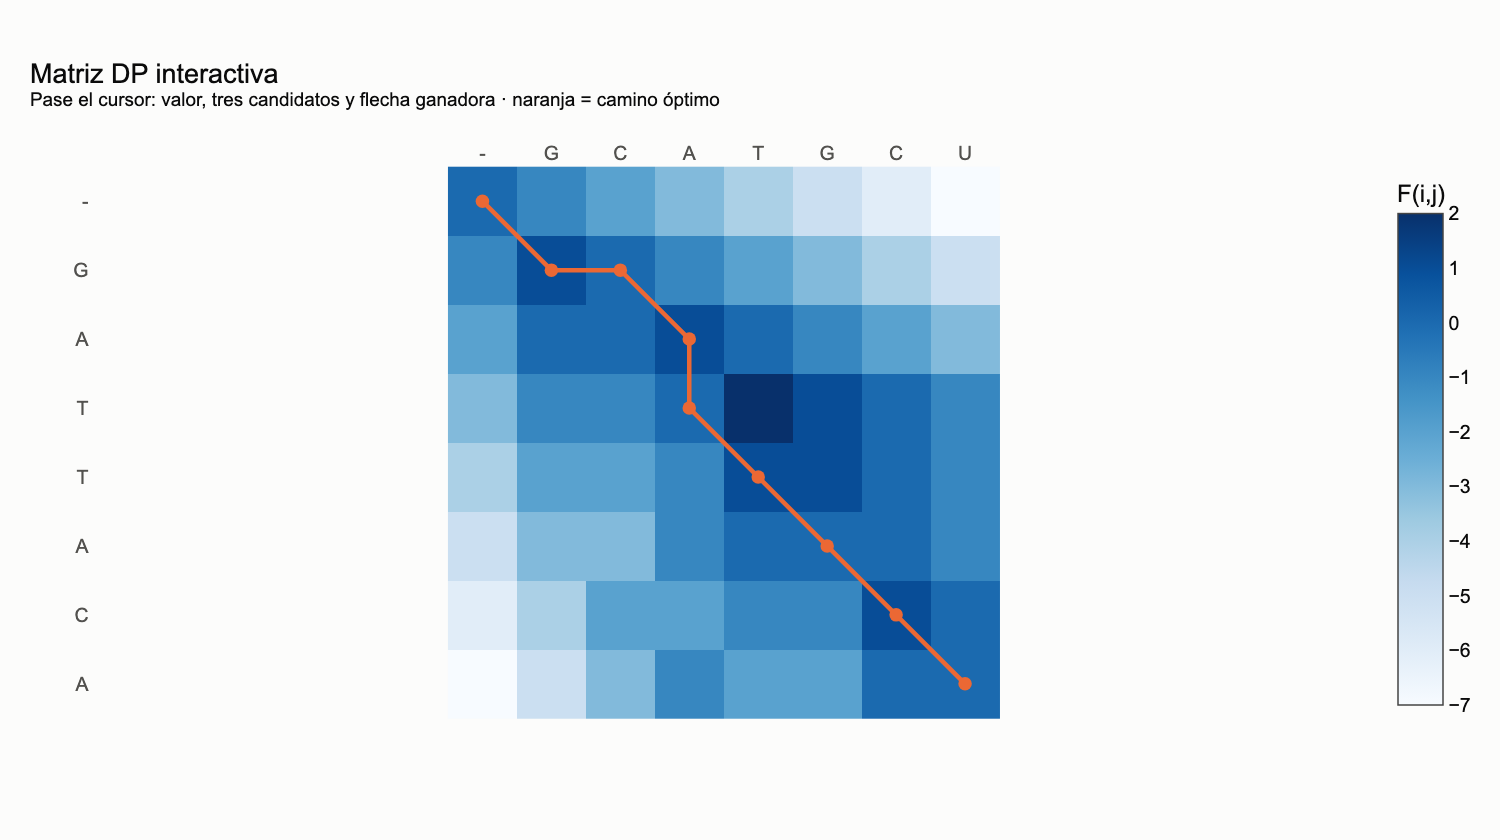

In [10]:
def dp_heatmap(a, b, F, T, cand, path, title):
    move_name = {DIAG: "↘ diagonal", UP: "↓ hueco en B", LEFT: "→ hueco en A", -1: "origen"}
    hover = []
    for i in range(len(a) + 1):
        row = []
        for j in range(len(b) + 1):
            head = f"F({i},{j}) = <b>{F[i,j]:.0f}</b><br>fila: {('-' + a)[i]} · columna: {('-' + b)[j]}"
            if i > 0 and j > 0:
                d, u, l = cand[i, j]
                head += (f"<br>candidatos → diag {d:.0f} · arriba {u:.0f} · izq {l:.0f}"
                         f"<br>ganó: {move_name[T[i,j]]}")
            else:
                head += "<br>borde: sólo huecos"
            row.append(head)
        hover.append(row)
    fig = go.Figure(go.Heatmap(z=F, x=list(range(len(b) + 1)), y=list(range(len(a) + 1)),
                               text=hover, hoverinfo="text", colorscale="Blues",
                               colorbar=dict(title="F(i,j)")))
    fig.add_trace(go.Scatter(x=[p[1] for p in path], y=[p[0] for p in path], mode="lines+markers",
                             line=dict(color=ec.ORANGE, width=3), marker=dict(size=9, color=ec.ORANGE),
                             name="camino óptimo", hoverinfo="skip"))
    fig.update_layout(title=dict(text=title), height=560, width=720,
                      margin=dict(t=110, l=60),
                      legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
    fig.update_xaxes(tickvals=list(range(len(b) + 1)), ticktext=list("-" + b), side="top", showgrid=False)
    fig.update_yaxes(tickvals=list(range(len(a) + 1)), ticktext=list("-" + a), autorange="reversed", showgrid=False,
                     scaleanchor="x", scaleratio=1)
    return fig

dp_heatmap(A, B, F, T, cand, path,
           "Matriz DP interactiva<br><sup>Pase el cursor: valor, tres candidatos y flecha ganadora · naranja = camino óptimo</sup>").show()

## 9. 🧪 Implementación y verificación contra Biopython

Un buen científico no confía en su propio código hasta **compararlo con una referencia independiente**. Biopython
trae `PairwiseAligner`, implementado en C. Si nuestro algoritmo es correcto, **el puntaje óptimo** debe coincidir
siempre (el alineamiento concreto puede diferir cuando hay empates, como vimos).

🤔 **Antes de ejecutar, prediga:** si generamos 200 pares de secuencias al azar de longitudes distintas, ¿en cuántos
coincidirá el puntaje?

In [11]:
aligner = PairwiseAligner()
aligner.mode = "global"
aligner.match_score, aligner.mismatch_score, aligner.gap_score = MATCH, MISMATCH, GAP

rng = np.random.default_rng(32)
agree = 0
for _ in range(200):
    a = "".join(rng.choice(list("ACGT"), rng.integers(1, 40)))
    b = "".join(rng.choice(list("ACGT"), rng.integers(1, 40)))
    agree += needleman_wunsch(a, b)[0][-1, -1] == aligner.score(a, b)
print(f"Puntajes idénticos en {agree} de 200 pares aleatorios")
print("Biopython para GATTACA/GCATGCU:", aligner.score(A, B))
print(aligner.align(A, B)[0])

Puntajes idénticos en 200 de 200 pares aleatorios
Biopython para GATTACA/GCATGCU: 0.0
target            0 G-ATTACA 7
                  0 |-||.-|. 8
query             0 GCATG-CU 7



## 10. Alineamiento local: Smith-Waterman

El alineamiento **global** obliga a alinear las secuencias **de punta a punta**. Eso tiene sentido si comparamos
dos versiones del mismo gen. Pero muchas veces la pregunta es otra: *¿hay una región parecida escondida dentro de
dos secuencias que por lo demás no se parecen?* Por ejemplo, un **dominio** proteico compartido por dos proteínas
muy distintas, o un **motivo** regulador.

Piense en dos libros diferentes que citan el **mismo párrafo** de un tercer autor. Comparar los libros completos
letra por letra daría un puntaje pésimo; lo interesante es **encontrar el párrafo compartido** e ignorar el resto.

En 1981 Temple Smith y Michael Waterman propusieron un cambio mínimo a la recurrencia: **agregar un cero**.

$$
H(i, j) \;=\; \max
\begin{cases}
\mathbf{0} & \text{empezar de nuevo aquí (olvidar el pasado)}\\
H(i-1, j-1) + s(a_i, b_j)\\
H(i-1, j) + d\\
H(i, j-1) + d
\end{cases}
\qquad H(i,0) = H(0,j) = 0
$$

| Diferencia | Needleman-Wunsch (global) | Smith-Waterman (local) |
|---|---|---|
| Bordes | $i\cdot d$, $j \cdot d$ (huecos obligatorios) | $0$ (empezar donde sea es gratis) |
| Piso | ninguno, puede ser negativo | **0**: una región mala nunca "contagia" a la siguiente |
| Dónde empieza el *traceback* | esquina $(n, m)$ | **la celda de valor máximo** en toda la matriz |
| Dónde termina | en $(0, 0)$ | al llegar a una celda con $H = 0$ |

El cero funciona como un botón de "reiniciar": si el puntaje acumulado se vuelve negativo, es mejor olvidar todo lo
anterior y empezar un alineamiento nuevo justo ahí.

In [12]:
def smith_waterman(a: str, b: str, match=MATCH, mismatch=MISMATCH, gap=GAP):
    n, m = len(a), len(b)
    H = np.zeros((n + 1, m + 1)); T = np.full((n + 1, m + 1), -1)
    cand = np.full((n + 1, m + 1, 3), np.nan)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            s = match if a[i - 1] == b[j - 1] else mismatch
            options = (H[i - 1, j - 1] + s, H[i - 1, j] + gap, H[i, j - 1] + gap)
            k = int(np.argmax(options))
            cand[i, j] = options
            if options[k] > 0:
                H[i, j], T[i, j] = options[k], k
            # si todo es <= 0, la celda queda en 0 y sin flecha (reinicio)
    i_max, j_max = np.unravel_index(np.argmax(H), H.shape)
    top, bottom, path = traceback(a, b, T, i_max, j_max, stop_at_zero=H)
    return H, T, cand, (top, bottom, path)

A2, B2 = "TTTTGATTACAGCCC", "AAAGGATTTACAGAA"          # comparten un núcleo parecido a "GATTACAG"
F2, T2, c2 = needleman_wunsch(A2, B2)
g_top, g_bot, g_path = traceback(A2, B2, T2)
H2, TH2, cH2, (l_top, l_bot, l_path) = smith_waterman(A2, B2)
print("GLOBAL (NW)  puntaje =", F2[-1, -1]); show_alignment(g_top, g_bot)
print("\nLOCAL (SW)   puntaje =", H2.max()); show_alignment(l_top, l_bot)

aligner_local = PairwiseAligner(mode="local", match_score=MATCH, mismatch_score=MISMATCH, gap_score=GAP)
print("\nVerificación con Biopython (local):", aligner_local.score(A2, B2))

GLOBAL (NW)  puntaje = 0.0
   T  T  T  T  G  A  -  T  T  A  C  A  G  C  C  C
   .  .  .  .  |  |     |  |  |  |  |  |     .  .
   A  A  A  G  G  A  T  T  T  A  C  A  G  -  A  A

LOCAL (SW)   puntaje = 7.0
   G  A  -  T  T  A  C  A  G
   |  |     |  |  |  |  |  |
   G  A  T  T  T  A  C  A  G

Verificación con Biopython (local): 7.0


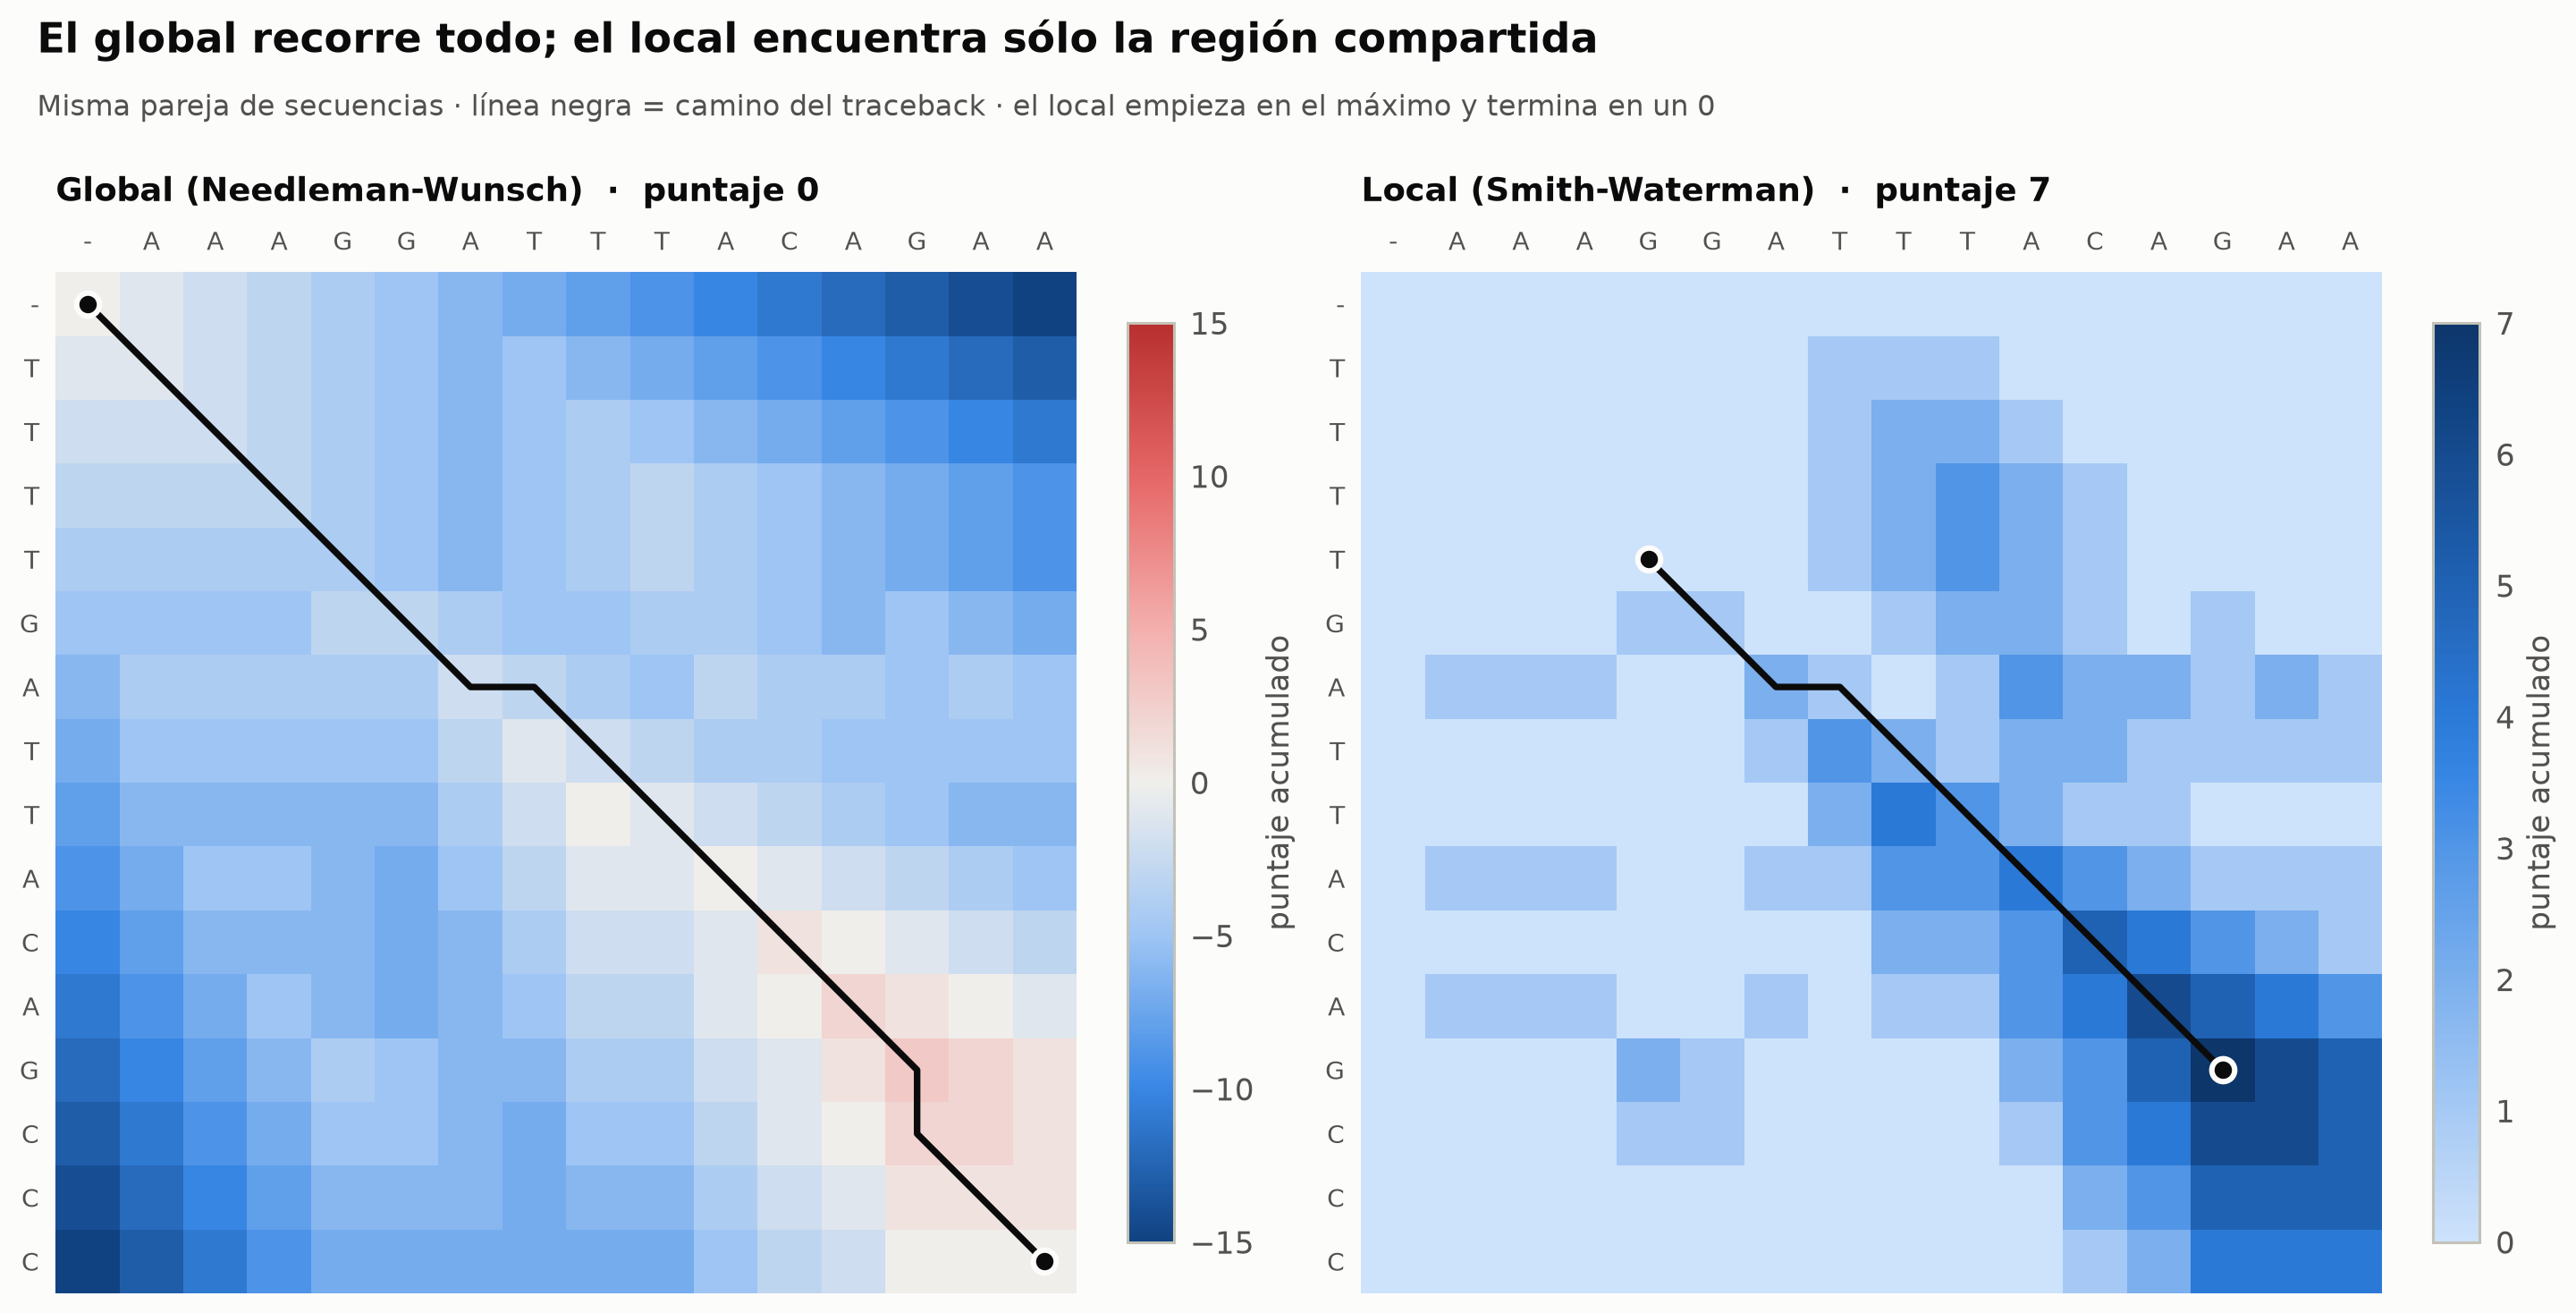

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.4))
panels = [(axes[0], F2, g_path, "Global (Needleman-Wunsch)", "RdBu"),
          (axes[1], H2, l_path, "Local (Smith-Waterman)", "Blues")]
for ax, M, pth, name, cmap in panels:
    lim = np.abs(M).max()
    im = ax.imshow(M, cmap="curso_div" if cmap == "RdBu" else "curso_seq",
                   vmin=-lim if cmap == "RdBu" else 0, vmax=lim)
    ax.plot([p[1] for p in pth], [p[0] for p in pth], color=ec.INK, lw=2.4)
    ax.scatter([pth[0][1], pth[-1][1]], [pth[0][0], pth[-1][0]], s=70, color=ec.INK,
               edgecolor=ec.SURFACE, linewidth=2, zorder=4)
    ax.set_xticks(range(len(B2) + 1)); ax.set_xticklabels(list("-" + B2), fontsize=9)
    ax.set_yticks(range(len(A2) + 1)); ax.set_yticklabels(list("-" + A2), fontsize=9)
    ax.xaxis.tick_top(); ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_title(f"{name}  ·  puntaje {M[pth[-1]] if name.startswith('Local') else M[-1,-1]:.0f}",
                 fontsize=12, loc="left", pad=26)
    fig.colorbar(im, ax=ax, shrink=0.75, label="puntaje acumulado")
ec.fig_title(fig, "El global recorre todo; el local encuentra sólo la región compartida",
             "Misma pareja de secuencias · línea negra = camino del traceback · el local empieza en el máximo y termina en un 0")
plt.show()

> 🔎 **Qué observamos.** En la matriz global aparecen muchos valores **negativos** (azul) y sólo unos pocos
> positivos (rojo): los extremos que no se parecen "cobran" su peaje y el puntaje final queda en 0. La matriz local nunca baja de cero, y el camino es corto: **sólo** recorre la región similar
> (el núcleo `GATT‑ACAG`), ignorando las colas `TTTT`/`AAA` y `CCC`/`AA`.

### ¿Cuál uso? Global, local o semiglobal

Existe un tercer modo, el **semiglobal** (*ends-free*): los huecos en los **extremos** no se castigan, pero dentro
del alineamiento sí. Es lo que se quiere cuando una secuencia corta debe caber **completa** dentro de una larga.

| Pregunta biológica | Modo | Ejemplo |
|---|---|---|
| ¿Cuán parecidos son estos dos genes ortólogos completos? | **Global** | gen *S* de SARS-CoV-2 frente al de SARS-CoV-1 |
| ¿Comparten algún dominio o motivo estas dos proteínas? | **Local** | búsqueda con BLAST (Lección 3.4) |
| ¿Dónde cae esta lectura de 150 nt en el genoma? | **Semiglobal** | mapeo de lecturas (Módulo 7) |
| ¿Se solapan los extremos de estas dos lecturas? | **Semiglobal** (*overlap*) | ensamblaje (Módulo 8) |

✅ **Compruebe su comprensión.** Si alinea localmente una secuencia consigo misma, ¿dónde estará la celda máxima y
qué valor tendrá?

## 11. ¿Cuánto cuesta un hueco? Penalización lineal y afín

Hasta ahora cada hueco cuesta lo mismo, $d$. Pero biológicamente **una** inserción de 5 bases (un solo evento
mutacional) es mucho más probable que **cinco** inserciones independientes de 1 base. Por eso los programas reales
usan la **penalización afín** (Gotoh, 1982): abrir un hueco cuesta caro y extenderlo cuesta poco.

$$
w(k) \;=\; \underbrace{g_{\text{open}}}_{\text{abrir}} \;+\; \underbrace{g_{\text{ext}}\,(k-1)}_{\text{extender}}
\qquad\text{frente a la lineal}\qquad w(k) = d\cdot k
$$

| Símbolo | Significado | Valores típicos (proteínas) |
|---|---|---|
| $k$ | longitud del hueco | — |
| $w(k)$ | costo total de un hueco de longitud $k$ | — |
| $g_{\text{open}}$ | costo de abrir el hueco | $-10$ a $-11$ |
| $g_{\text{ext}}$ | costo de cada posición adicional | $-0.5$ a $-1$ |

Con penalización afín la recurrencia necesita **tres matrices** (una para cada "estado": en diagonal, dentro de un
hueco en A, dentro de un hueco en B), pero la idea es la misma. Biopython la implementa con
`open_gap_score` y `extend_gap_score`.

Veamos de forma interactiva cómo el **costo del hueco** cambia el alineamiento óptimo. Mueva el deslizador: con huecos
baratos el algoritmo abre muchos para forzar coincidencias; con huecos caros prefiere aceptar sustituciones.

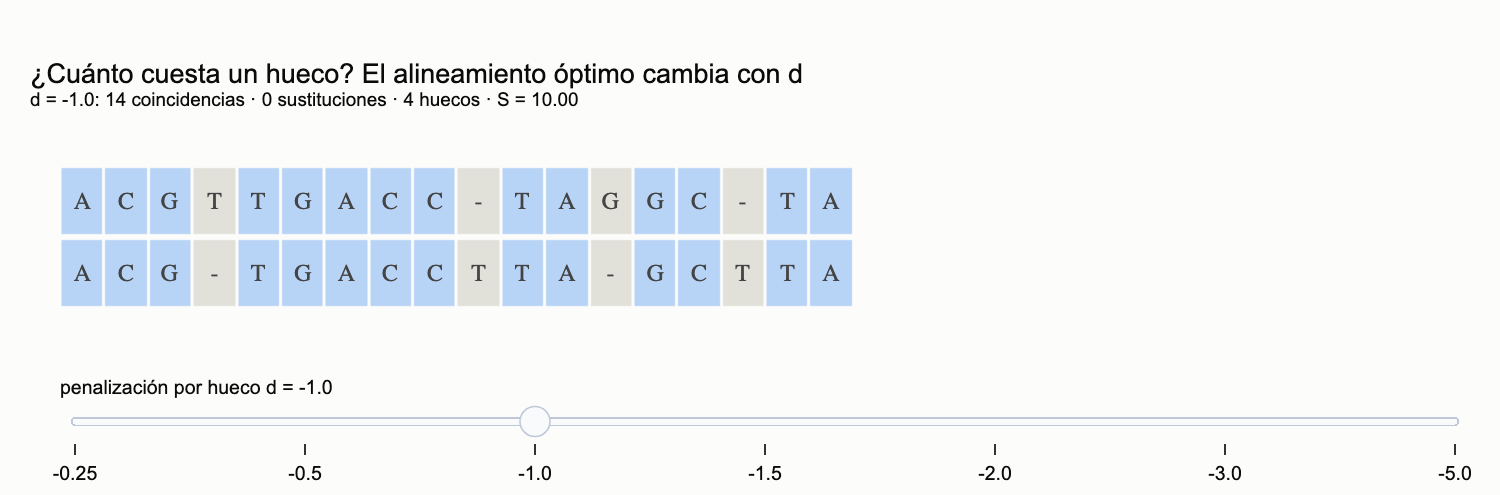

In [14]:
X, Y = "ACGTTGACCTAGGCTA", "ACGTGACCTTAGCTTA"
gap_values = [-0.25, -0.5, -1.0, -1.5, -2.0, -3.0, -5.0]

def alignment_tracks(top, bottom):
    kind = [2 if "-" in (t, b) else (0 if t == b else 1) for t, b in zip(top, bottom)]
    return kind

frames_p, steps_p = [], []
max_len = len(X) + len(Y)
for g in gap_values:
    Fg, Tg, _ = needleman_wunsch(X, Y, gap=g)
    tg, bg, _ = traceback(X, Y, Tg)
    kind = alignment_tracks(tg, bg)
    n_gap = sum(k == 2 for k in kind); n_mis = sum(k == 1 for k in kind); n_mat = sum(k == 0 for k in kind)
    z = [kind, kind]
    text = [list(tg), list(bg)]
    hover = [[f"columna {c+1}: {tg[c]} / {bg[c]}<br>{['coincidencia','sustitución','hueco'][kind[c]]}"
              for c in range(len(tg))]] * 2
    trace = go.Heatmap(z=z, text=text, texttemplate="%{text}", textfont=dict(size=16, family="DejaVu Sans Mono"),
                       customdata=hover, hovertemplate="%{customdata}<extra></extra>",
                       colorscale=[[0, "#b7d3f6"], [0.33, "#b7d3f6"], [0.34, "#f7c3ab"], [0.66, "#f7c3ab"],
                                   [0.67, "#e1e0d9"], [1, "#e1e0d9"]], zmin=0, zmax=2, showscale=False, xgap=2, ygap=4)
    label = f"d = {g}: {n_mat} coincidencias · {n_mis} sustituciones · {n_gap} huecos · S = {Fg[-1,-1]:.2f}"
    frames_p.append(go.Frame(data=[trace], name=str(g), layout=dict(title=dict(text=
        "¿Cuánto cuesta un hueco? El alineamiento óptimo cambia con d<br><sup>" + label + "</sup>"))))
    steps_p.append(dict(method="animate", label=str(g),
                        args=[[str(g)], dict(mode="immediate", frame=dict(duration=0, redraw=True), transition=dict(duration=0))]))

start = gap_values.index(-1.0)
fig = go.Figure(data=frames_p[start].data, frames=frames_p)
fig.update_layout(title=frames_p[start].layout.title, height=330, margin=dict(t=110, b=90, l=40, r=20),
                  sliders=[dict(active=start, steps=steps_p, currentvalue=dict(prefix="penalización por hueco d = "),
                                pad=dict(t=40))])
fig.update_xaxes(visible=False, range=[-0.5, max_len - 0.5]); fig.update_yaxes(visible=False, autorange="reversed")
fig.show()

> 🔎 **Qué observamos.** Con $d$ cercano a 0 el alineamiento se llena de huecos (azul = coincidencias por todas
> partes, pero a costa de "romper" las secuencias). Con $d$ muy negativo desaparecen los huecos y aparecen
> sustituciones (naranja). **No existe un único alineamiento correcto**: el resultado depende del modelo de puntaje,
> que es una hipótesis sobre cómo evolucionan las secuencias. Elegir bien ese modelo es el tema de la Lección 3.3.

## 12. 🧪 El costo del algoritmo: tiempo y memoria

La matriz tiene $(n+1)(m+1)$ celdas y cada una cuesta un número fijo de operaciones, así que:

$$
\text{tiempo} \;=\; O(n\,m), \qquad \text{memoria} \;=\; O(n\,m)
$$

Si duplicamos la longitud de **ambas** secuencias, el trabajo se **cuadruplica**. En una gráfica log–log eso se ve
como una recta de **pendiente 2**.

🤔 **Antes de ejecutar, prediga:** si 100 × 100 tarda $t$ segundos, ¿cuánto tardará 400 × 400?

In [15]:
lengths = [50, 100, 200, 300, 400, 600]
times_py, times_c = [], []
rng = np.random.default_rng(1)
for L in lengths:
    a = "".join(rng.choice(list("ACGT"), L)); b = "".join(rng.choice(list("ACGT"), L))
    runs = []
    for _ in range(3 if L <= 200 else 2):                   # mejor de varias repeticiones: menos ruido
        t0 = time.perf_counter(); needleman_wunsch(a, b); runs.append(time.perf_counter() - t0)
    times_py.append(min(runs))
    t0 = time.perf_counter()
    for _ in range(20): aligner.score(a, b)
    times_c.append((time.perf_counter() - t0) / 20)
bench = pd.DataFrame({"n": lengths, "python_s": times_py, "biopython_C_s": times_c})
bench["ratio"] = bench.python_s / bench.biopython_C_s
slope = np.polyfit(np.log10(bench.n[1:]), np.log10(bench.python_s[1:]), 1)[0]   # sin el tramo con costos fijos
print(f"Pendiente log–log de nuestra implementación (n ≥ 100): {slope:.2f}  (teoría: 2)")
bench.style.format({"python_s": "{:.4f}", "biopython_C_s": "{:.6f}", "ratio": "{:.0f}×"})

Pendiente log–log de nuestra implementación (n ≥ 100): 2.50  (teoría: 2)


,n,python_s,biopython_C_s,ratio
0,50,0.0097,0.000013,765×
1,100,0.0164,0.000016,1052×
2,200,0.0666,0.000056,1189×
3,300,0.2934,0.000122,2409×
4,400,0.5422,0.000401,1351×
5,600,1.2328,0.001216,1014×


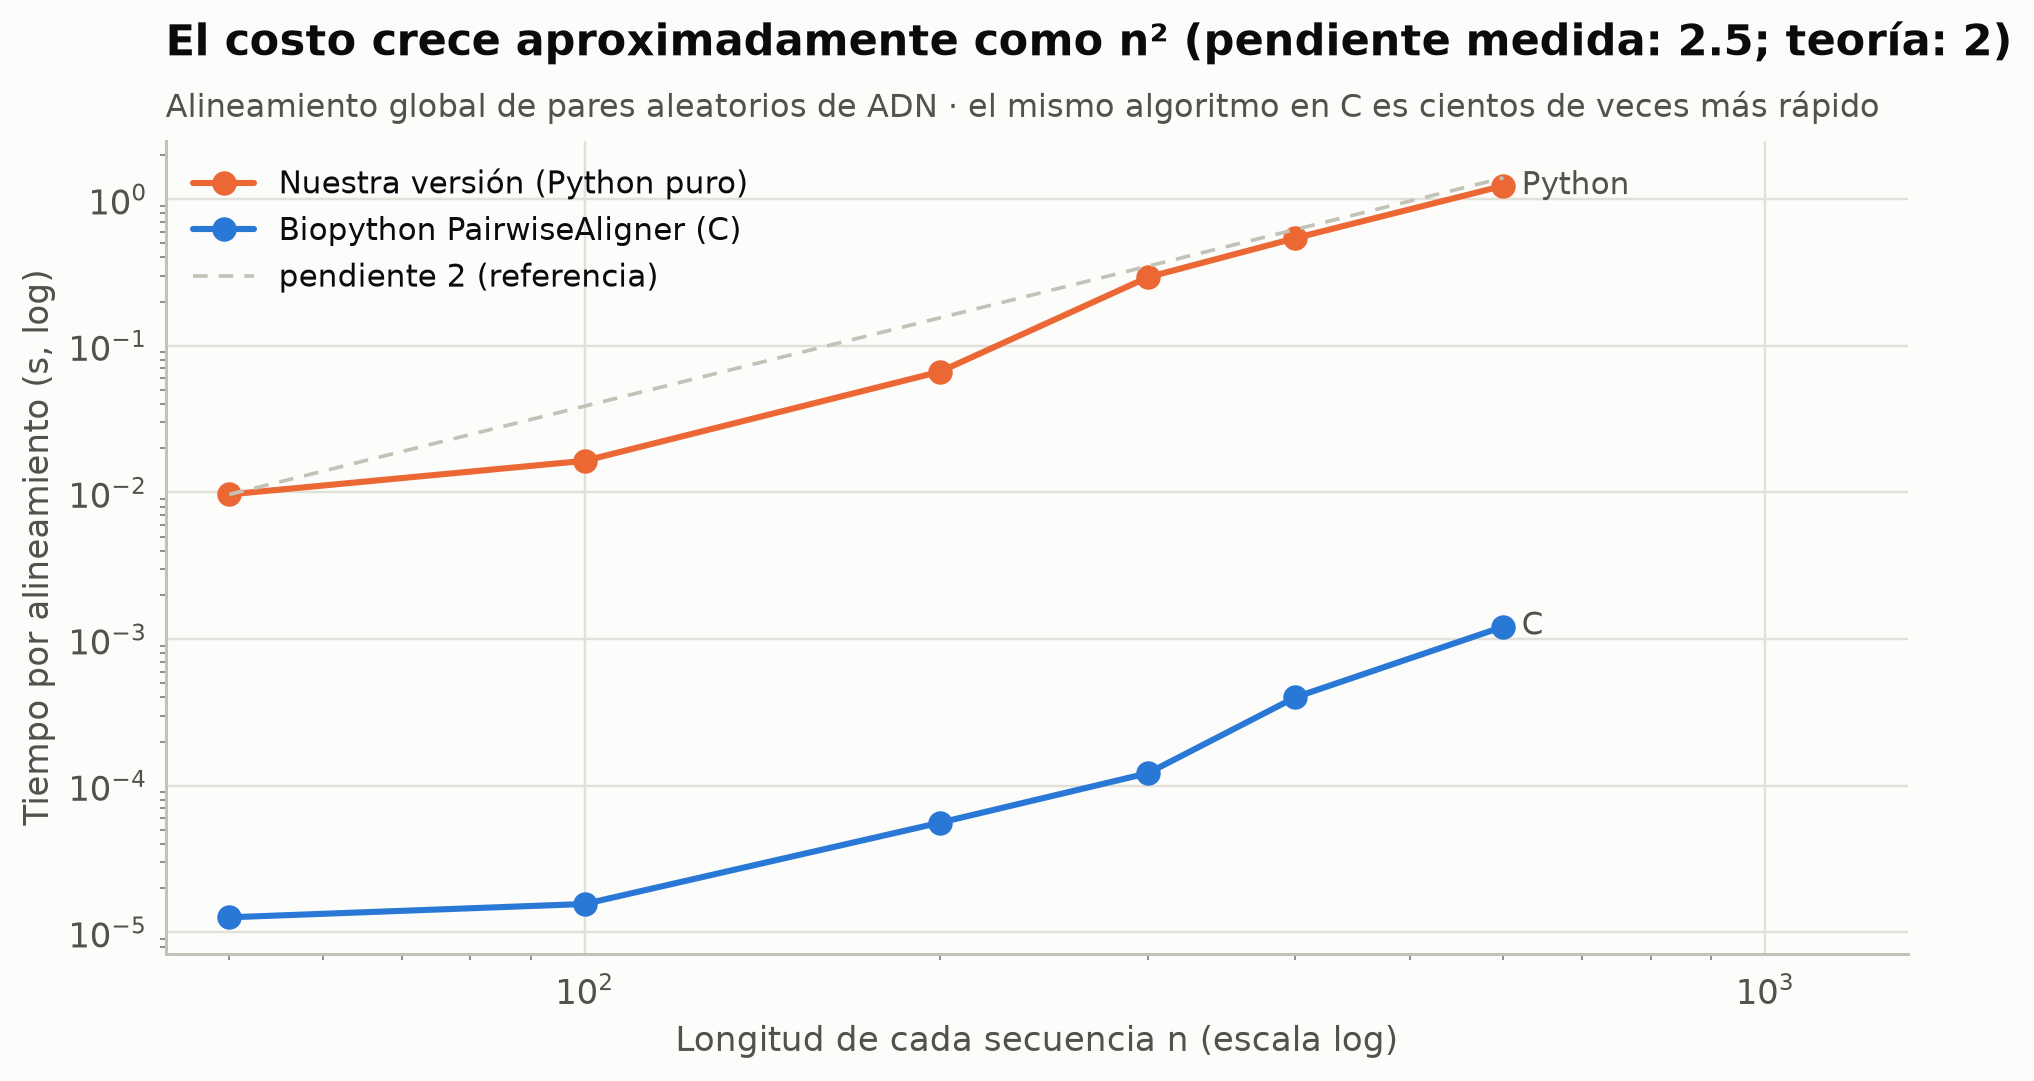

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.loglog(bench.n, bench.python_s, "o-", color=ec.ORANGE, label="Nuestra versión (Python puro)")
ax.loglog(bench.n, bench.biopython_C_s, "o-", color=ec.BLUE, label="Biopython PairwiseAligner (C)")
ref = bench.python_s.iloc[0] * (bench.n / bench.n.iloc[0]) ** 2
ax.loglog(bench.n, ref, color=ec.BASELINE, lw=1.2, ls=(0, (4, 3)), label="pendiente 2 (referencia)")
ec.label_end(ax, bench.n.iloc[-1], bench.python_s.iloc[-1], "Python")
ec.label_end(ax, bench.n.iloc[-1], bench.biopython_C_s.iloc[-1], "C")
ax.set_xlim(right=bench.n.max() * 2.2)
ax.set_xlabel("Longitud de cada secuencia n (escala log)")
ax.set_ylabel("Tiempo por alineamiento (s, log)")
ax.grid(True, which="major", axis="both")
ax.legend(loc="upper left")
ec.title(ax, f"El costo crece aproximadamente como n² (pendiente medida: {slope:.1f}; teoría: 2)",
         "Alineamiento global de pares aleatorios de ADN · el mismo algoritmo en C es cientos de veces más rápido")
plt.show()

> 🔎 **Qué observamos.** La pendiente medida está cerca de 2, como predice la teoría (en una computadora real suele
> salir algo por encima o por debajo: la memoria caché, el recolector de basura y otros procesos añaden ruido; por eso
> medimos varias veces y nos quedamos con el mejor tiempo). Biopython implementa **el mismo algoritmo**
> pero en C, y es cientos de veces más rápido: la complejidad es la misma, cambia la constante (recuerde la Lección
> 0.1 con `numpy`).
>
> ¿Y la memoria? Para alinear dos genomas completos de SARS-CoV-2 y SARS-CoV-1 (~30 000 nt cada uno) la matriz
> tendría $9 \times 10^{8}$ celdas: con 8 bytes por celda, **¡más de 7 GB!** Por eso existen variantes en espacio
> lineal (Hirschberg, 1975) y, para bases de datos gigantes, las **heurísticas** como BLAST (Lección 3.4), que
> renuncian a garantizar el óptimo a cambio de velocidad.

## 13. 🧪 Caso real: el RBD de la Spike de SARS-CoV-2 frente al de SARS-CoV-1

El **dominio de unión al receptor** (RBD) es la parte de la proteína Spike que se une al receptor ACE2 de nuestras
células. Tomemos el RBD de SARS-CoV-2 (residuos ~319–541) y la región correspondiente de SARS-CoV-1 (~306–527) y
alineémoslos globalmente con nuestra implementación (usando todavía el puntaje simple +1/−1/−1; en la Lección 3.3
veremos por qué para proteínas conviene BLOSUM62).

🤔 **Antes de ejecutar, prediga:** ¿qué porcentaje de identidad espera entre los RBD de los dos virus?

In [17]:
from Bio import Entrez
Entrez.email = "su.correo@ejemplo.com"

def load_genbank(acc):
    """Primero la copia local del curso, luego el NCBI y por último la copia en GitHub."""
    for path in (f"../data/{acc}.gb", f"{acc}.gb"):
        if os.path.exists(path):
            return SeqIO.read(path, "genbank")
    try:
        with Entrez.efetch(db="nuccore", id=acc, rettype="gbwithparts", retmode="text") as h:
            open(f"{acc}.gb", "w").write(h.read())
    except Exception as err:
        print("NCBI no respondió:", err, "→ copia del curso")
        urllib.request.urlretrieve(f"{RAW}/data/{acc}.gb", f"{acc}.gb")
    return SeqIO.read(f"{acc}.gb", "genbank")

def spike_protein(record):
    return next(f for f in record.features
                if f.type == "CDS" and f.qualifiers.get("gene") == ["S"]).qualifiers["translation"][0]

cov2, cov1 = load_genbank("NC_045512.2"), load_genbank("NC_004718.3")
rbd2 = spike_protein(cov2)[318:541]        # residuos 319–541 (1-based)
rbd1 = spike_protein(cov1)[305:527]        # residuos 306–527 (1-based)
print(f"RBD SARS-CoV-2: {len(rbd2)} aa · RBD SARS-CoV-1: {len(rbd1)} aa")

t0 = time.perf_counter()
Fr, Tr, _ = needleman_wunsch(rbd2, rbd1)
r_top, r_bot, r_path = traceback(rbd2, rbd1, Tr)
print(f"Matriz de {Fr.size:,} celdas llenada en {time.perf_counter() - t0:.2f} s · puntaje = {Fr[-1,-1]:.0f}"
      f" (Biopython: {aligner.score(rbd2, rbd1):.0f})")
pairs = [(x, y) for x, y in zip(r_top, r_bot)]
n_id = sum(x == y for x, y in pairs); n_gap = sum("-" in p for p in pairs)
print(f"Identidad: {n_id}/{len(pairs)} columnas = {n_id/len(pairs):.1%} · huecos: {n_gap}")
for k in range(0, 60, 60):
    show_alignment(r_top[k:k+60], r_bot[k:k+60])

RBD SARS-CoV-2: 223 aa · RBD SARS-CoV-1: 222 aa
Matriz de 49,952 celdas llenada en 0.17 s · puntaje = 105 (Biopython: 105)
Identidad: 165/225 columnas = 73.3% · huecos: 5
   R  V  Q  P  T  E  S  I  V  R  F  P  N  I  T  N  L  C  P  F  G  E  V  F  N  A  T  R  F  A  S  V  Y  A  W  N  R  K  R  I  S  N  C  V  A  D  Y  S  V  L  Y  N  S  A  S  F  S  T  F  K
   |  |  .  |  .  .  .  .  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  .  |  .  |  |  |  |  |  .  |  |  .  |  |  |  |  |  |  |  |  |  |  |  |  |  |  .  .  |  |  |  |  |
   R  V  V  P  S  G  D  V  V  R  F  P  N  I  T  N  L  C  P  F  G  E  V  F  N  A  T  K  F  P  S  V  Y  A  W  E  R  K  K  I  S  N  C  V  A  D  Y  S  V  L  Y  N  S  T  F  F  S  T  F  K


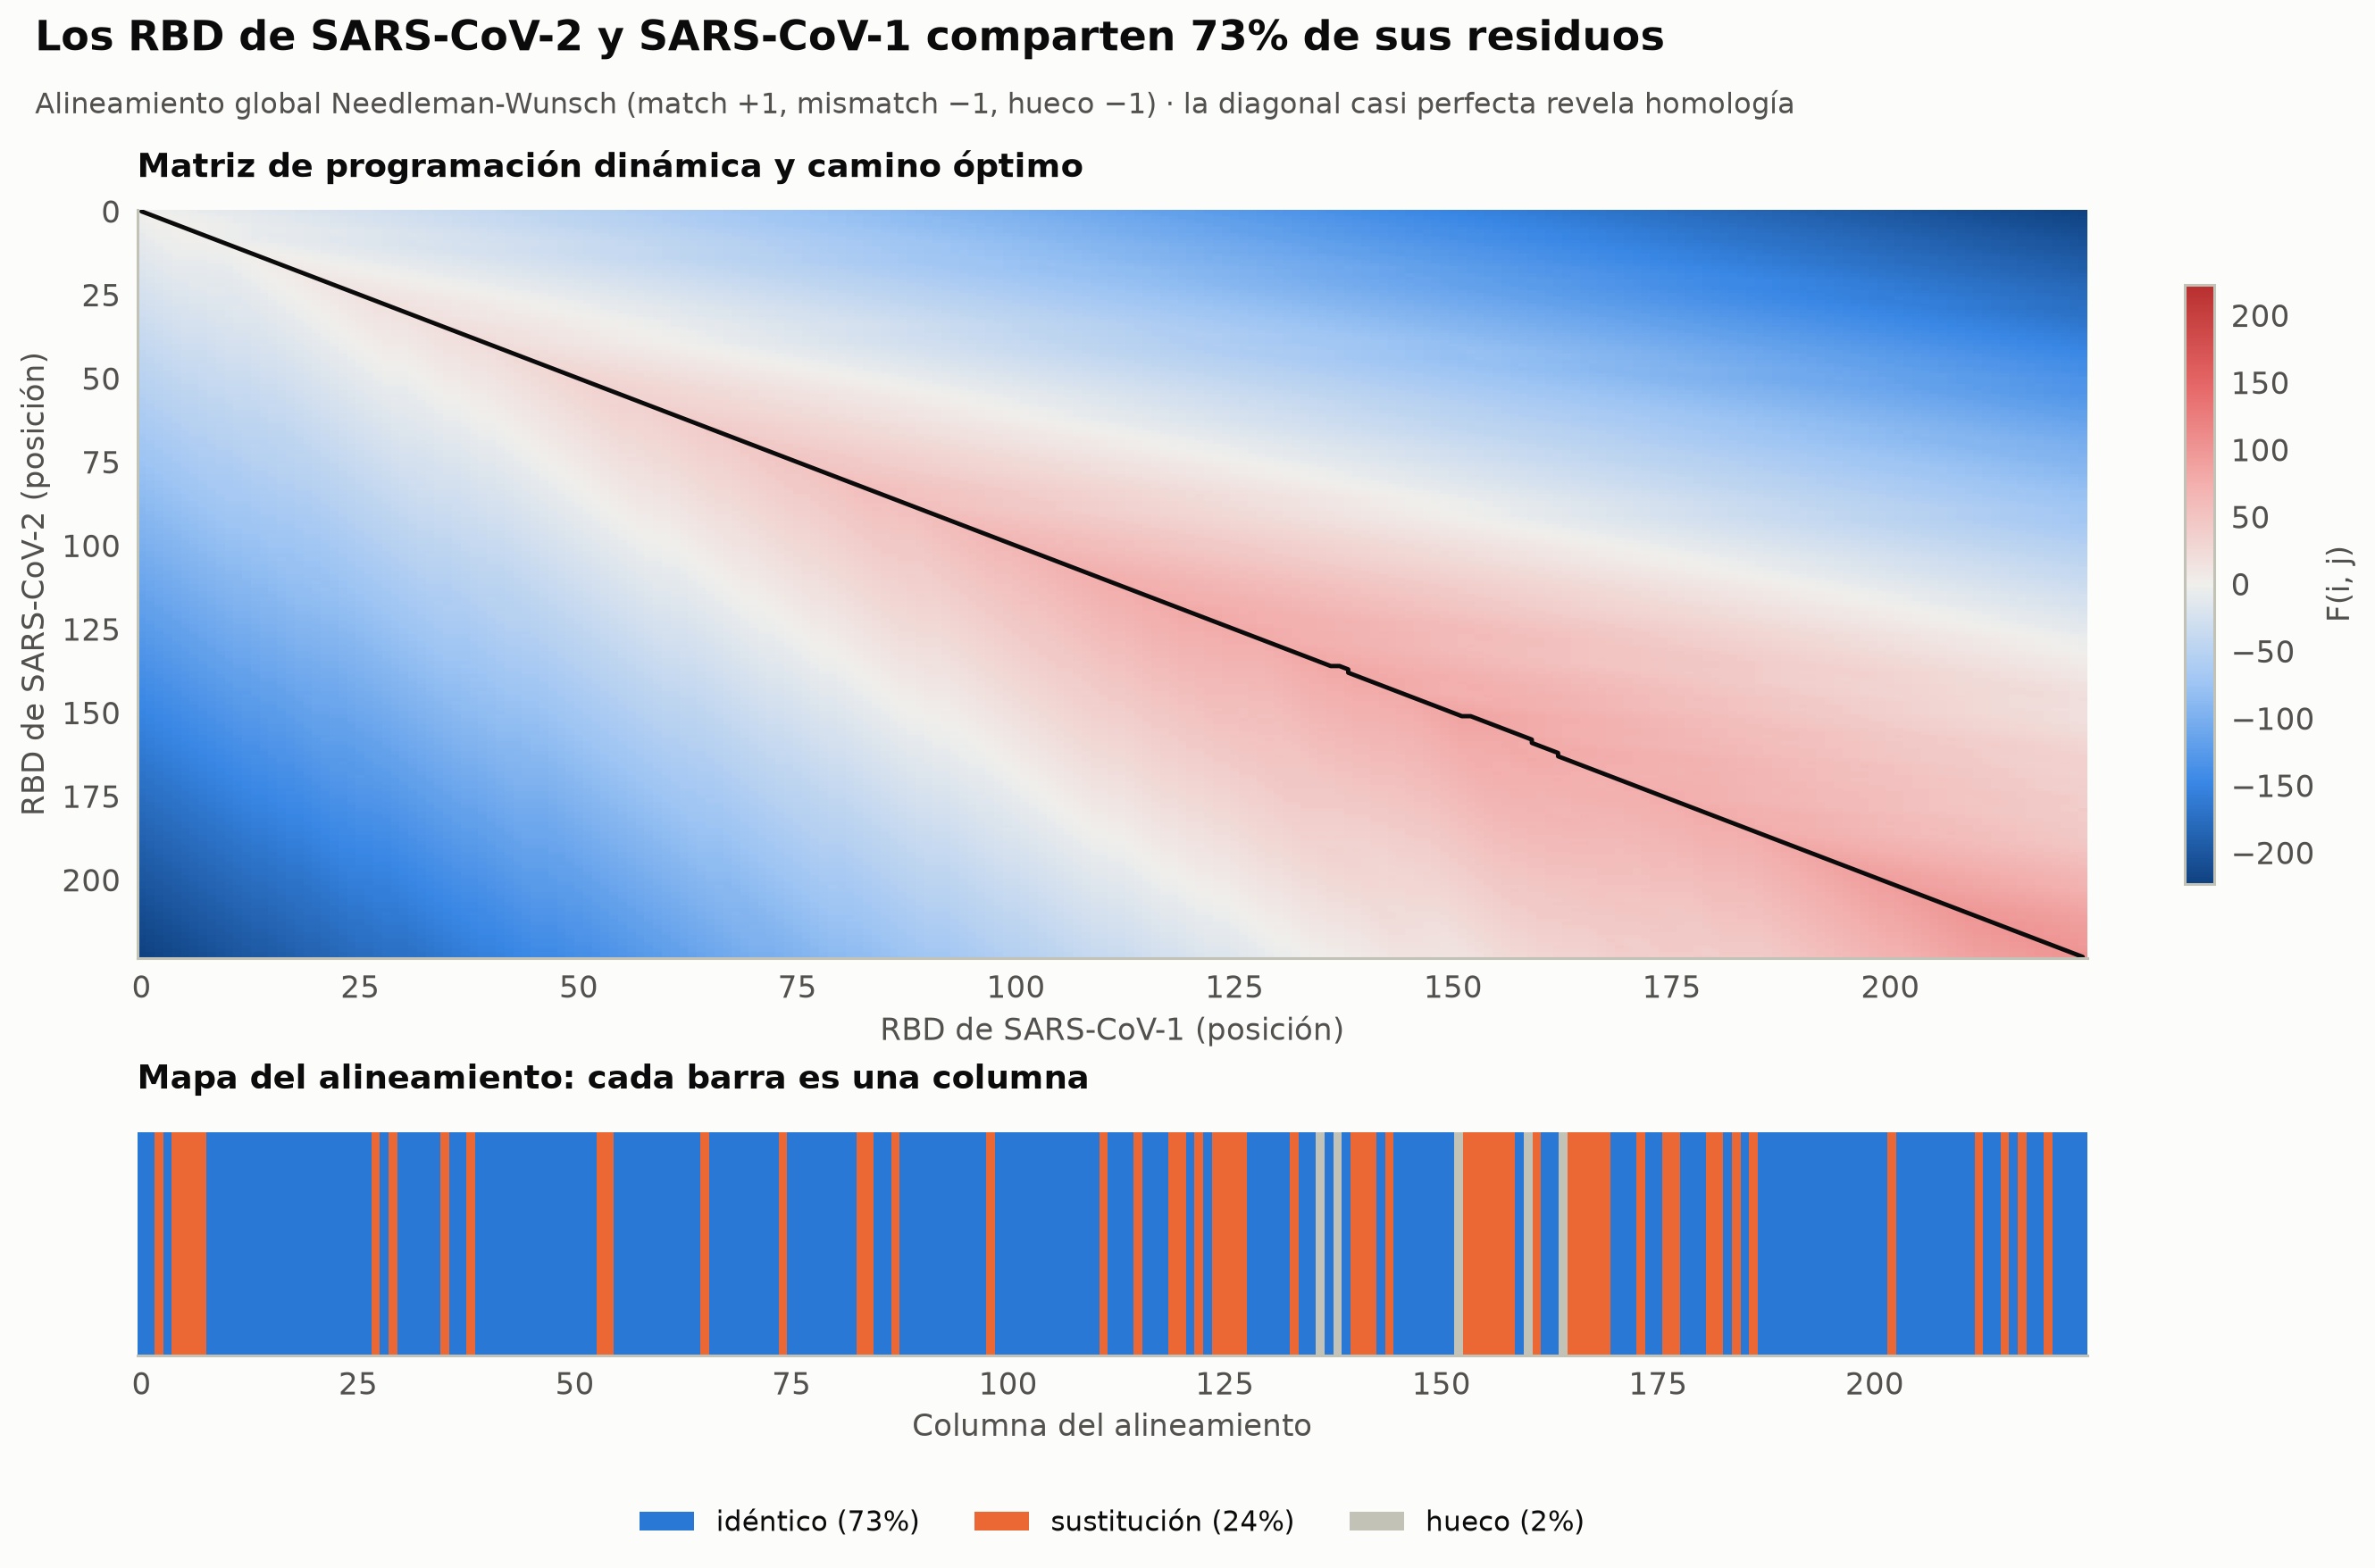

In [18]:
kind = np.array([2 if "-" in p else (0 if p[0] == p[1] else 1) for p in pairs])
L = len(kind)
fig, (ax_m, ax_s) = plt.subplots(2, 1, figsize=(12, 7.2), height_ratios=[3.2, 1])
im = ax_m.imshow(Fr, cmap="curso_div", vmin=-np.abs(Fr).max(), vmax=np.abs(Fr).max(), aspect="auto")
ax_m.plot([p[1] for p in r_path], [p[0] for p in r_path], color=ec.INK, lw=1.6)
ax_m.set_xlabel("RBD de SARS-CoV-1 (posición)"); ax_m.set_ylabel("RBD de SARS-CoV-2 (posición)")
ax_m.grid(False)
fig.colorbar(im, ax=ax_m, shrink=0.8, label="F(i, j)")
ax_m.set_title("Matriz de programación dinámica y camino óptimo", fontsize=12, loc="left")

colors = np.array([C_MATCH, C_MISMATCH, C_GAP])[kind]
ax_s.bar(np.arange(L), np.ones(L), width=1.0, color=colors, linewidth=0)
ax_s.set_xlim(-0.5, L - 0.5); ax_s.set_yticks([]); ax_s.grid(False)
ax_s.set_xlabel("Columna del alineamiento")
for s in ("left",): ax_s.spines[s].set_visible(False)
handles = [Rectangle((0, 0), 1, 1, color=c) for c in (C_MATCH, C_MISMATCH, C_GAP)]
ax_s.legend(handles, [f"idéntico ({(kind==0).mean():.0%})", f"sustitución ({(kind==1).mean():.0%})",
                      f"hueco ({(kind==2).mean():.0%})"], ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.55))
ax_s.set_title("Mapa del alineamiento: cada barra es una columna", fontsize=12, loc="left")
ec.fig_title(fig, f"Los RBD de SARS-CoV-2 y SARS-CoV-1 comparten {n_id/len(pairs):.0%} de sus residuos",
             "Alineamiento global Needleman-Wunsch (match +1, mismatch −1, hueco −1) · la diagonal casi perfecta revela homología")
plt.show()

> 🔎 **Qué observamos.** El camino óptimo corre casi pegado a la **diagonal**: las dos proteínas tienen longitudes
> parecidas y muy pocos huecos. Alrededor de tres cuartas partes de las posiciones son idénticas: los RBD de ambos
> virus son claramente **homólogos** (comparten un ancestro), aunque las sustituciones se concentran en ciertas
> zonas. Esas diferencias explican, en parte, por qué los dos virus se unen a ACE2 con afinidades distintas.

## ✍️ Ejercicios

**Ejercicio 1 — A mano.** Con el mismo esquema (+1/−1/−1), llene a mano la matriz de Needleman-Wunsch para
`ACG` frente a `AG`. ¿Cuál es el puntaje óptimo y cuál el alineamiento? Verifíquelo con `needleman_wunsch`.

**Ejercicio 2 — Contar alineamientos óptimos.** Modifique la recurrencia para que, además del puntaje, cuente
**cuántos caminos** alcanzan el óptimo en cada celda (sume los conteos de todas las flechas que empatan). ¿Cuántos
alineamientos óptimos tiene `GATTACA` frente a `GCATGCU`?

**Ejercicio 3 — Local en un caso biológico.** Busque con Smith-Waterman el motivo `GGATCC` (sitio de BamHI) dentro de
los primeros 3 000 nt del genoma de SARS-CoV-2 permitiendo sustituciones. ¿Cuál es la mejor coincidencia y dónde está?

**Ejercicio 4 — Penalización afín.** Con `PairwiseAligner` alinee de nuevo los dos RBD usando la matriz
BLOSUM62 (un adelanto de la Lección 3.3: `substitution_matrices.load("BLOSUM62")`), `open_gap_score = -10` y
`extend_gap_score = -0.5`, los valores por defecto de BLASTP. ¿Cuántas columnas con hueco quedan ahora frente a las
del esquema lineal +1/−1/−1? ¿Por qué?

In [19]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
F_e, T_e, _ = needleman_wunsch("ACG", "AG")
print(F_e.astype(int))
t_e, b_e, _ = traceback("ACG", "AG", T_e)
print("puntaje =", F_e[-1, -1]); show_alignment(t_e, b_e)

[[ 0 -1 -2]
 [-1  1  0]
 [-2  0  0]
 [-3 -1  1]]
puntaje = 1.0
   A  C  G
   |     |
   A  -  G


In [20]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
def count_optimal(a, b, match=MATCH, mismatch=MISMATCH, gap=GAP):
    n, m = len(a), len(b)
    F = np.zeros((n + 1, m + 1)); N = np.zeros((n + 1, m + 1), dtype=object)
    F[:, 0] = np.arange(n + 1) * gap; F[0, :] = np.arange(m + 1) * gap
    N[:, 0] = 1; N[0, :] = 1
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            s = match if a[i - 1] == b[j - 1] else mismatch
            opts = [(F[i-1, j-1] + s, N[i-1, j-1]), (F[i-1, j] + gap, N[i-1, j]), (F[i, j-1] + gap, N[i, j-1])]
            best = max(o[0] for o in opts)
            F[i, j] = best; N[i, j] = sum(c for v, c in opts if v == best)
    return F[-1, -1], N[-1, -1]
print("puntaje, número de alineamientos óptimos:", count_optimal(A, B))

puntaje, número de alineamientos óptimos: (np.float64(0.0), 3)


In [21]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
genome_head = str(cov2.seq[:3000])
aligner_motif = PairwiseAligner(mode="local", match_score=2, mismatch_score=-1, gap_score=-3)
best = aligner_motif.align(genome_head, "GGATCC")[0]
print("puntaje:", best.score); print(best)
print("posición en el genoma (1-based):", best.aligned[0][0][0] + 1)

puntaje: 10.0
target          718 GATCC 723
                  0 |||||   5
query             1 GATCC   6

posición en el genoma (1-based): 719


In [22]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
from Bio.Align import substitution_matrices
affine = PairwiseAligner(mode="global", substitution_matrix=substitution_matrices.load("BLOSUM62"),
                         open_gap_score=-10, extend_gap_score=-0.5)
aln = affine.align(rbd2, rbd1)[0]
gaps = sum(1 for x, y in zip(aln[0], aln[1]) if "-" in (x, y))
print(f"puntaje = {aln.score} · columnas con hueco = {gaps} (esquema lineal +1/−1/−1: {n_gap})")
print("Abrir un hueco cuesta −10: sólo vale la pena si evita varias sustituciones malas.")
print(aln)

puntaje = 902.0 · columnas con hueco = 1 (esquema lineal +1/−1/−1: 5)
Abrir un hueco cuesta −10: sólo vale la pena si evita varias sustituciones malas.
target            0 RVQPTESIVRFPNITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFK
                  0 ||.|....|||||||||||||||||||.|.|||||.||.||||||||||||||..|||||
query             0 RVVPSGDVVRFPNITNLCPFGEVFNATKFPSVYAWERKKISNCVADYSVLYNSTFFSTFK

target           60 CYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNS
                 60 |||||.||||||||.||||||||..||.||||||||||.||||||||||||.|||.|||.
query            60 CYGVSATKLNDLCFSNVYADSFVVKGDDVRQIAPGQTGVIADYNYKLPDDFMGCVLAWNT

target          120 NNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQ
                120 .|.|....|||||.||..|...|.|||||||.........||.-....|||.||..|||.
query           120 RNIDATSTGNYNYKYRYLRHGKLRPFERDISNVPFSPDGKPCT-PPALNCYWPLNDYGFY

target          180 PTNGVGYQPYRVVVLSFELLHAPATVCGPKKSTNLVKNKCVNF 223
                180 .|.|.|||||||||||||||.|||||||

## 📌 Resumen

* **Alinear** es escribir dos secuencias una sobre otra con huecos para enfrentar posiciones homólogas; un esquema
  de **puntaje** (match, mismatch, hueco) convierte cada alineamiento en un número.
* El número de alineamientos crece **exponencialmente** ($\sim 4^n/\sqrt{\pi n}$): la fuerza bruta es imposible.
* El **principio de optimalidad** permite resolver el problema con una tabla: $F(i,j)$ depende sólo de tres
  vecinas. Esto es **programación dinámica**.
* **Needleman-Wunsch** (global) inicializa los bordes con huecos y hace el *traceback* desde $(n,m)$.
  **Smith-Waterman** (local) agrega un **0** a la recurrencia y hace el *traceback* desde la celda máxima.
* El costo es $O(nm)$ en tiempo y memoria: exacto pero caro para genomas completos o bases de datos gigantes.
* El resultado depende del **modelo de puntaje** (sustituciones y huecos, lineales o afines).

**Próxima lección (3.3):** matrices de sustitución PAM y BLOSUM — de dónde salen los números que reemplazarán
nuestro simple +1/−1.

## 📚 Para profundizar

* Needleman, S. B. & Wunsch, C. D. (1970). A general method applicable to the search for similarities in the amino
  acid sequence of two proteins. *Journal of Molecular Biology* 48(3): 443–453.
* Smith, T. F. & Waterman, M. S. (1981). Identification of common molecular subsequences. *Journal of Molecular
  Biology* 147(1): 195–197.
* Gotoh, O. (1982). An improved algorithm for matching biological sequences. *Journal of Molecular Biology*
  162(3): 705–708.
* Durbin, R., Eddy, S. R., Krogh, A. & Mitchison, G. (1998). *Biological Sequence Analysis: Probabilistic Models of
  Proteins and Nucleic Acids*. Cambridge University Press — capítulo 2.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)